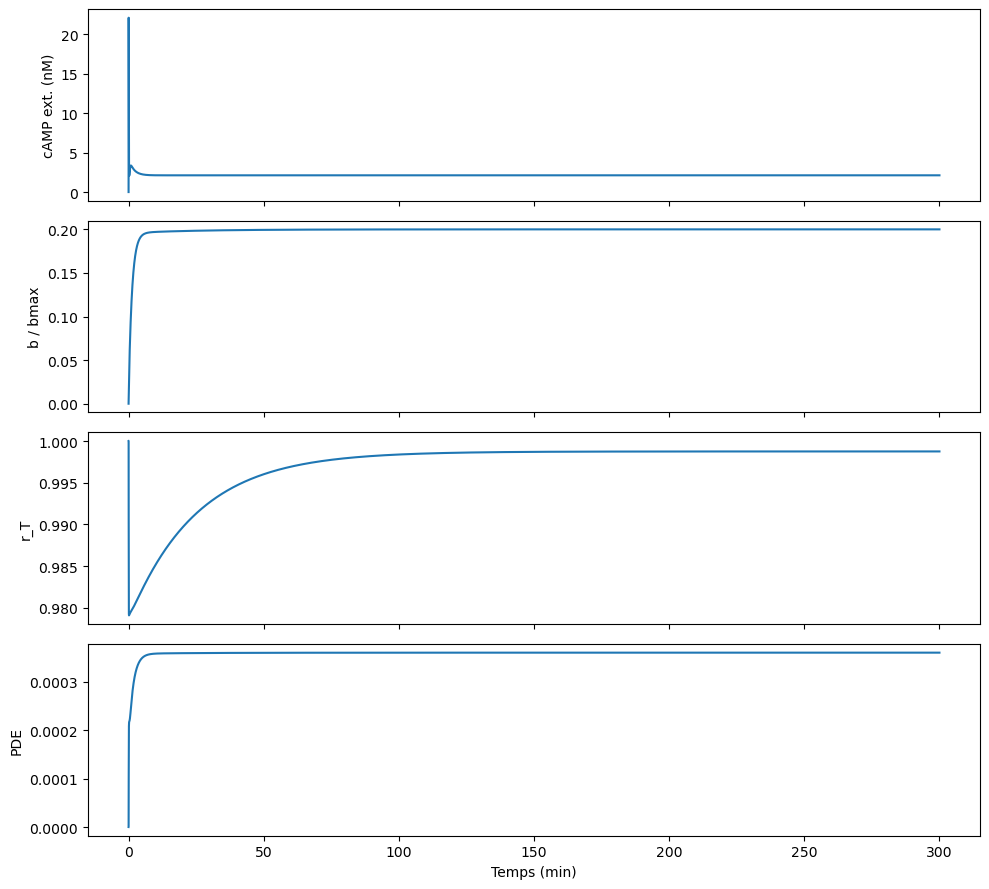

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Paramètres repris du code
# =========================

TIME_SIMU = 300.0       # minutes
dt = 0.001              # minutes
n_steps = int(TIME_SIMU / dt)

J = 0.4
k_PDE = 1e5

F1_base = 2.0
F2_base = 0.04
N_HILL = 4
K_h = 3e-8

q_s = 6e-6
k_t = 0.8
b_max = q_s / k_t

K_relay = 5e-5

PDE_threshold = 5e-8
hill_n_PDE = 2

# Cellule pionnière

f0 = 0.2
K_relay = 5e-4
PDE_inhibition_threshold = 1e-5
PDE_rate = 0.02
PDE_decay = 0.1

# =========================
# Conditions initiales
# =========================

c = 0.0       # cAMP extracellulaire
b = 0.0       # cAMP intracellulaire
r_T = 1.0     # récepteurs actifs
PDE = 0.0

times = np.zeros(n_steps)
c_trace = np.zeros(n_steps)
b_trace = np.zeros(n_steps)
r_trace = np.zeros(n_steps)
pde_trace = np.zeros(n_steps)

# =========================
# Simulation 0D
# =========================

for i in range(n_steps):
    t = i * dt

    c_pos = max(c, 0.0)

    hill_c = c_pos**N_HILL / (K_h**N_HILL + c_pos**N_HILL + 1e-60)

    f1_eff = F1_base * hill_c

    F_val = r_T * (f0 + (1.0 - f0) * hill_c)

    inhibition = 1.0 / (1.0 + (PDE / PDE_inhibition_threshold)**2)

    camp_prod = K_relay * (b / b_max) * inhibition
    camp_deg = J * c + k_PDE * PDE * c

    pde_prod = PDE_rate * c_pos**hill_n_PDE / (
        PDE_threshold**hill_n_PDE + c_pos**hill_n_PDE + 1e-60
    )

    dc = camp_prod - camp_deg
    db = q_s * F_val - k_t * b
    dr = -f1_eff * r_T + F2_base * (1.0 - r_T)
    dPDE = pde_prod - PDE_decay * PDE

    c += dc * dt
    b += db * dt
    r_T += dr * dt
    PDE += dPDE * dt

    c = max(c, 0.0)
    b = max(b, 0.0)
    r_T = min(max(r_T, 0.0), 1.0)
    PDE = max(PDE, 0.0)

    times[i] = t
    c_trace[i] = c
    b_trace[i] = b
    r_trace[i] = r_T
    pde_trace[i] = PDE

# =========================
# Affichage
# =========================

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)

axes[0].plot(times, c_trace * 1e9)
axes[0].set_ylabel("cAMP ext. (nM)")

axes[1].plot(times, b_trace / b_max)
axes[1].set_ylabel("b / bmax")

axes[2].plot(times, r_trace)
axes[2].set_ylabel("r_T")

axes[3].plot(times, pde_trace)
axes[3].set_ylabel("PDE")
axes[3].set_xlabel("Temps (min)")

plt.tight_layout()
plt.show()

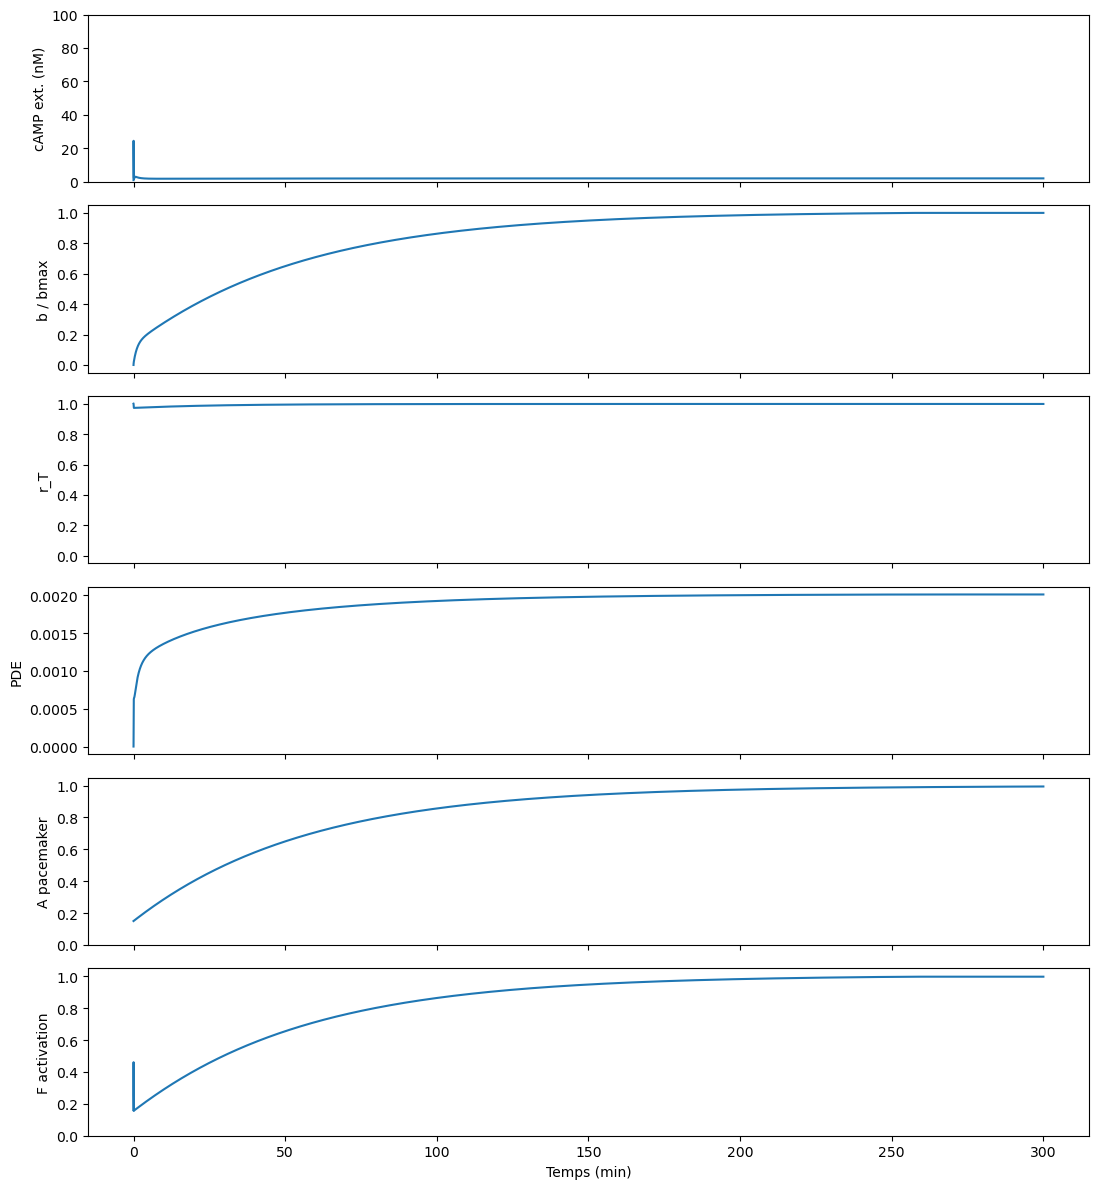

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Test 0D : oscillateur cAMP minimal
# =========================
# Objectif : obtenir une cellule pionnière qui pulse toute seule.
# Le modèle ajoute une variable lente de récupération interne, A,
# qui représente l'état pacemaker/famine de la cellule.

TIME_SIMU = 300.0       # minutes
dt = 0.001              # minutes
n_steps = int(TIME_SIMU / dt)

# Dégradation extracellulaire basale
J = 0.25
k_PDE = 6e4

# Récepteurs actifs / désensibilisation
F1_base = 3.0
F2_base = 0.035
N_HILL = 4
K_h = 3e-8              # 30 nM

# cAMP intracellulaire b
q_s = 7e-6
k_t = 0.9
b_max = q_s / k_t

# Sécrétion du cAMP extracellulaire
K_relay = 2.5e-3

# PDE / RegA
PDE_threshold = 3e-8
hill_n_PDE = 2
PDE_rate = 0.035
PDE_decay = 0.08

# Inhibition de la sécrétion par la PDE
PDE_inhibition_threshold = 2e-5

# Variable pacemaker lente
# A remonte lentement quand la cellule est récupérée,
# puis chute fortement pendant un pulse.
A = 0.15
A_recovery_rate = 0.018
A_drop_rate = 1.4
A_min = 0.02
A_max = 1.0

# Petite activité basale de pionnière
f0 = 0.01

# =========================
# Conditions initiales
# =========================

c = 0.0       # cAMP extracellulaire
b = 0.0       # cAMP intracellulaire
r_T = 1.0     # fraction de récepteurs actifs
PDE = 0.0

# Petite amorce initiale, juste pour éviter un système parfaitement nul.
c += 1e-9

# =========================
# Traces
# =========================

times = np.zeros(n_steps)
c_trace = np.zeros(n_steps)
b_trace = np.zeros(n_steps)
r_trace = np.zeros(n_steps)
pde_trace = np.zeros(n_steps)
A_trace = np.zeros(n_steps)
F_trace = np.zeros(n_steps)

# =========================
# Simulation 0D
# =========================

for i in range(n_steps):
    t = i * dt

    c_pos = max(c, 0.0)

    hill_c = c_pos**N_HILL / (K_h**N_HILL + c_pos**N_HILL + 1e-60)

    # Activation effective :
    # - f0 donne une très faible activité basale
    # - A donne l'état pacemaker interne
    # - hill_c donne le relais induit par le cAMP externe
    activation = f0 + A + (1.0 - f0) * hill_c
    activation = min(activation, 1.0)

    F_val = r_T * activation

    # Désensibilisation rapide quand le cAMP externe est haut
    f1_eff = F1_base * hill_c

    # PDE : production en réponse au cAMP externe
    pde_prod = PDE_rate * c_pos**hill_n_PDE / (
        PDE_threshold**hill_n_PDE + c_pos**hill_n_PDE + 1e-60
    )

    # Inhibition de la sécrétion quand la PDE accumulée est forte
    inhibition = 1.0 / (1.0 + (PDE / PDE_inhibition_threshold)**2)

    # Production / dégradation extracellulaire
    camp_prod = K_relay * (b / b_max) * inhibition
    camp_deg = J * c + k_PDE * PDE * c

    dc = camp_prod - camp_deg
    db = q_s * F_val - k_t * b
    dr = -f1_eff * r_T + F2_base * (1.0 - r_T)
    dPDE = pde_prod - PDE_decay * PDE

    # Variable pacemaker lente :
    # - elle récupère quand la cellule est sensible
    # - elle chute quand la cellule est activée / désensibilisée
    recovery_drive = r_T * (1.0 - hill_c)
    pulse_drive = hill_c * (b / b_max)
    dA = A_recovery_rate * recovery_drive * (A_max - A) - A_drop_rate * pulse_drive * (A - A_min)

    c += dc * dt
    b += db * dt
    r_T += dr * dt
    PDE += dPDE * dt
    A += dA * dt

    c = max(c, 0.0)
    b = max(b, 0.0)
    r_T = min(max(r_T, 0.0), 1.0)
    PDE = max(PDE, 0.0)
    A = min(max(A, A_min), A_max)

    times[i] = t
    c_trace[i] = c
    b_trace[i] = b / b_max
    r_trace[i] = r_T
    pde_trace[i] = PDE
    A_trace[i] = A
    F_trace[i] = F_val

# =========================
# Affichage
# =========================

fig, axes = plt.subplots(6, 1, figsize=(11, 12), sharex=True)

axes[0].plot(times, c_trace * 1e9)
axes[0].set_ylabel("cAMP ext. (nM)")
axes[0].set_ylim(0, max(100, np.nanmax(c_trace * 1e9) * 1.1))

axes[1].plot(times, b_trace)
axes[1].set_ylabel("b / bmax")

axes[2].plot(times, r_trace)
axes[2].set_ylabel("r_T")
axes[2].set_ylim(-0.05, 1.05)

axes[3].plot(times, pde_trace)
axes[3].set_ylabel("PDE")

axes[4].plot(times, A_trace)
axes[4].set_ylabel("A pacemaker")
axes[4].set_ylim(0, 1.05)

axes[5].plot(times, F_trace)
axes[5].set_ylabel("F activation")
axes[5].set_xlabel("Temps (min)")
axes[5].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

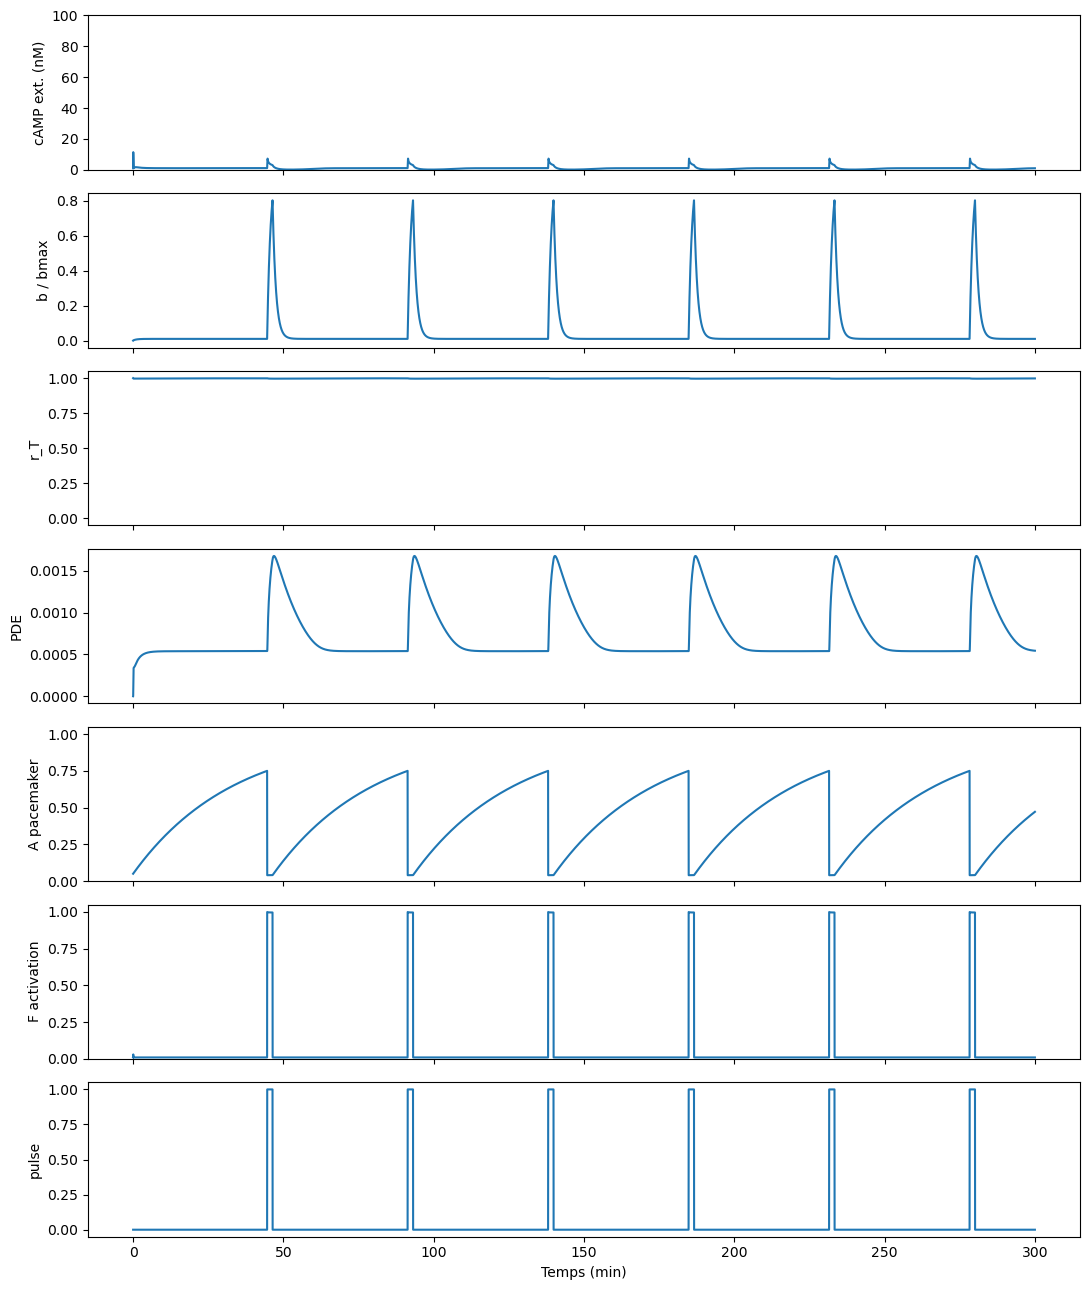

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Test 0D : oscillateur cAMP minimal
# =========================
# Objectif : obtenir une cellule pionnière qui pulse toute seule.
# Le modèle ajoute une variable lente de récupération interne, A,
# qui représente l'état pacemaker/famine de la cellule.

TIME_SIMU = 300.0       # minutes
dt = 0.001              # minutes
n_steps = int(TIME_SIMU / dt)

# Dégradation extracellulaire basale
J = 0.25
k_PDE = 6e4

# Récepteurs actifs / désensibilisation
F1_base = 3.0
F2_base = 0.035
N_HILL = 4
K_h = 3e-8              # 30 nM

# cAMP intracellulaire b
q_s = 7e-6
k_t = 0.9
b_max = q_s / k_t

# Sécrétion du cAMP extracellulaire
K_relay = 2.5e-3

# PDE / RegA
PDE_threshold = 3e-8
hill_n_PDE = 2
PDE_rate = 0.035
PDE_decay = 0.08

# Inhibition de la sécrétion par la PDE
PDE_inhibition_threshold = 2e-5

# Variable pacemaker lente
# A représente l'état interne de famine / maturité oscillatoire.
# Quand A dépasse A_trigger, la cellule déclenche un pulse autonome.
A = 0.05
A_recovery_rate = 0.030
A_min = 0.02
A_max = 1.0
A_trigger = 0.75
A_reset = 0.04

# Pulse autonome de la cellule pionnière
pulse_active = False
pulse_timer = 0.0
pulse_duration = 1.8       # minutes
pulse_strength = 1.0

# Petite activité basale de pionnière
f0 = 0.01

# =========================
# Conditions initiales
# =========================

c = 0.0       # cAMP extracellulaire
b = 0.0       # cAMP intracellulaire
r_T = 1.0     # fraction de récepteurs actifs
PDE = 0.0

# Petite amorce initiale, juste pour éviter un système parfaitement nul.
c += 1e-9

# =========================
# Traces
# =========================

times = np.zeros(n_steps)
c_trace = np.zeros(n_steps)
b_trace = np.zeros(n_steps)
r_trace = np.zeros(n_steps)
pde_trace = np.zeros(n_steps)
A_trace = np.zeros(n_steps)
F_trace = np.zeros(n_steps)
pulse_trace = np.zeros(n_steps)

# =========================
# Simulation 0D
# =========================

for i in range(n_steps):
    t = i * dt

    c_pos = max(c, 0.0)

    hill_c = c_pos**N_HILL / (K_h**N_HILL + c_pos**N_HILL + 1e-60)

    # Déclenchement autonome d'une cellule pionnière.
    # Tant que la cellule est sensible et que le cAMP externe est bas,
    # A remonte. Quand A dépasse un seuil, la cellule pulse.
    if (not pulse_active) and (A >= A_trigger) and (r_T > 0.8) and (hill_c < 0.2):
        pulse_active = True
        pulse_timer = pulse_duration
        A = A_reset

    if pulse_active:
        pacemaker_drive = pulse_strength
        pulse_timer -= dt
        if pulse_timer <= 0.0:
            pulse_active = False
            pulse_timer = 0.0
    else:
        pacemaker_drive = 0.0

    # Activation effective :
    # - f0 donne une très faible activité basale
    # - hill_c donne le relais induit par le cAMP externe
    # - pacemaker_drive donne le pulse autonome de la cellule pionnière
    activation = f0 + pacemaker_drive + (1.0 - f0) * hill_c
    activation = min(activation, 1.0)

    F_val = r_T * activation

    # Désensibilisation rapide quand le cAMP externe est haut
    f1_eff = F1_base * hill_c

    # PDE : production en réponse au cAMP externe
    pde_prod = PDE_rate * c_pos**hill_n_PDE / (
        PDE_threshold**hill_n_PDE + c_pos**hill_n_PDE + 1e-60
    )

    # Inhibition de la sécrétion quand la PDE accumulée est forte
    inhibition = 1.0 / (1.0 + (PDE / PDE_inhibition_threshold)**2)

    # Production / dégradation extracellulaire
    camp_prod = K_relay * (b / b_max) * inhibition
    camp_deg = J * c + k_PDE * PDE * c

    dc = camp_prod - camp_deg
    db = q_s * F_val - k_t * b
    dr = -f1_eff * r_T + F2_base * (1.0 - r_T)
    dPDE = pde_prod - PDE_decay * PDE

    # Variable pacemaker lente :
    # elle récupère seulement quand la cellule est sensible
    # et quand le cAMP externe est suffisamment bas.
    if pulse_active:
        dA = 0.0
    else:
        recovery_drive = r_T * (1.0 - hill_c)
        dA = A_recovery_rate * recovery_drive * (A_max - A)

    c += dc * dt
    b += db * dt
    r_T += dr * dt
    PDE += dPDE * dt
    A += dA * dt

    c = max(c, 0.0)
    b = max(b, 0.0)
    r_T = min(max(r_T, 0.0), 1.0)
    PDE = max(PDE, 0.0)
    A = min(max(A, A_min), A_max)

    times[i] = t
    c_trace[i] = c
    b_trace[i] = b / b_max
    r_trace[i] = r_T
    pde_trace[i] = PDE
    A_trace[i] = A
    F_trace[i] = F_val
    pulse_trace[i] = 1.0 if pulse_active else 0.0

# =========================
# Affichage
# =========================

fig, axes = plt.subplots(7, 1, figsize=(11, 13), sharex=True)

axes[0].plot(times, c_trace * 1e9)
axes[0].set_ylabel("cAMP ext. (nM)")
axes[0].set_ylim(0, max(100, np.nanmax(c_trace * 1e9) * 1.1))

axes[1].plot(times, b_trace)
axes[1].set_ylabel("b / bmax")

axes[2].plot(times, r_trace)
axes[2].set_ylabel("r_T")
axes[2].set_ylim(-0.05, 1.05)

axes[3].plot(times, pde_trace)
axes[3].set_ylabel("PDE")

axes[4].plot(times, A_trace)
axes[4].set_ylabel("A pacemaker")
axes[4].set_ylim(0, 1.05)

axes[5].plot(times, F_trace)
axes[5].set_ylabel("F activation")
axes[5].set_ylim(0, 1.05)

axes[6].plot(times, pulse_trace)
axes[6].set_ylabel("pulse")
axes[6].set_xlabel("Temps (min)")
axes[6].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

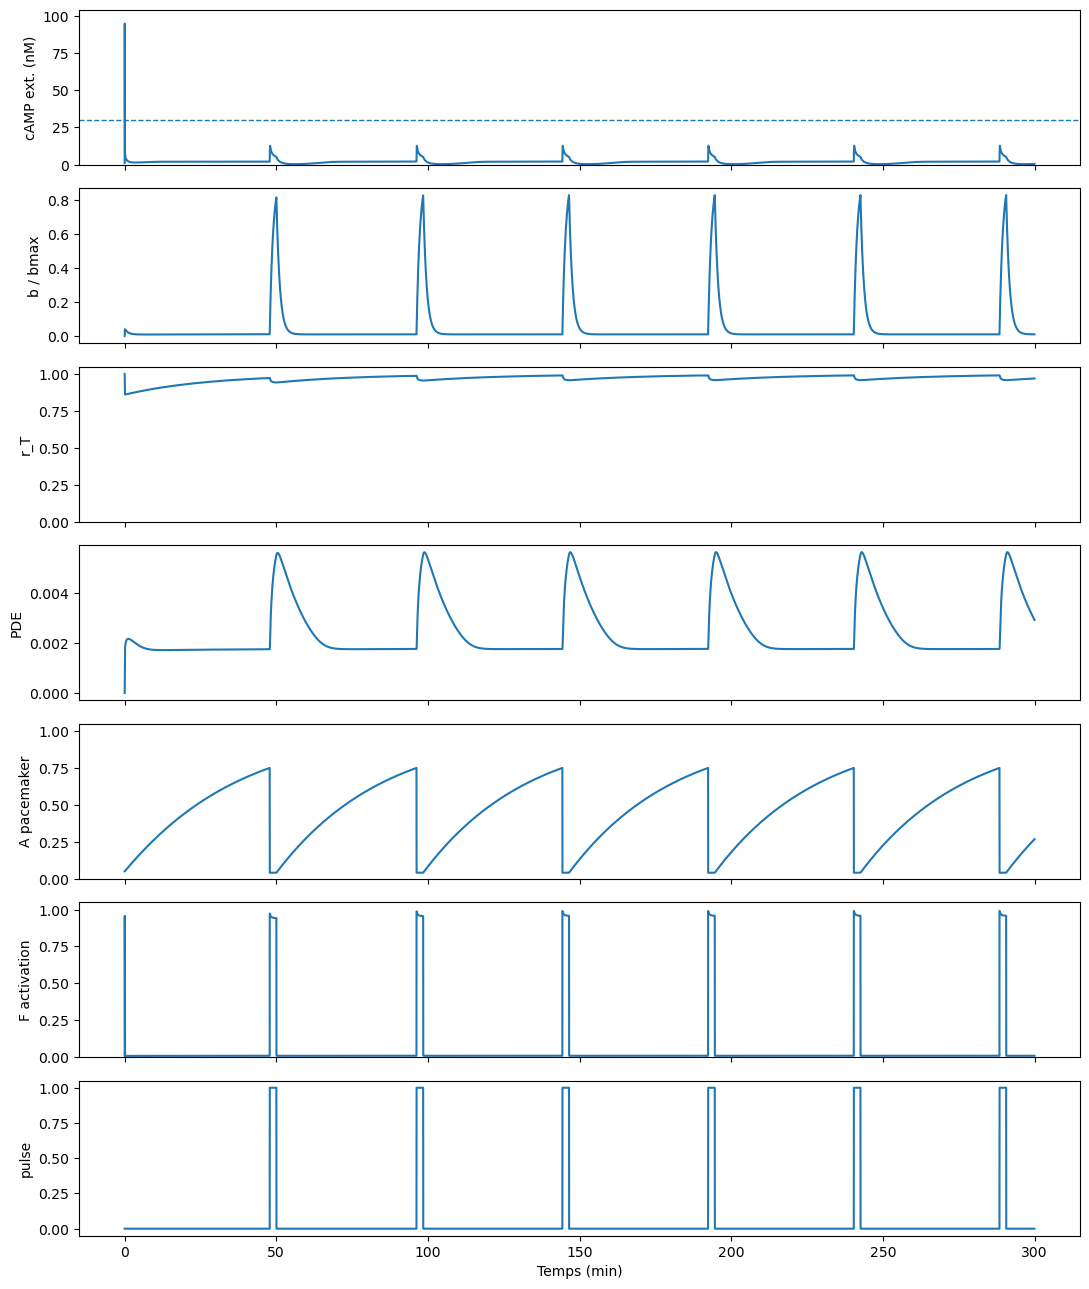

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Test 0D : oscillateur cAMP minimal
# =========================
# Objectif : obtenir une cellule pionnière qui pulse toute seule.
# Le modèle ajoute une variable lente de récupération interne, A,
# qui représente l'état pacemaker/famine de la cellule.

TIME_SIMU = 300.0       # minutes
dt = 0.001              # minutes
n_steps = int(TIME_SIMU / dt)

# Dégradation extracellulaire basale
J = 0.25
k_PDE = 6e4

# Récepteurs actifs / désensibilisation
F1_base = 3.0
F2_base = 0.035
N_HILL = 4
K_h = 3e-8              # 30 nM

# cAMP intracellulaire b
q_s = 7e-6
k_t = 0.9
b_max = q_s / k_t

# Sécrétion du cAMP extracellulaire
K_relay = 1.0e-2

# PDE / RegA
PDE_threshold = 3e-8
hill_n_PDE = 2
PDE_rate = 0.035
PDE_decay = 0.08

# Inhibition de la sécrétion par la PDE
# Valeur volontairement un peu plus haute pour laisser le pulse de cAMP
# dépasser le seuil d'activation des récepteurs avant que la PDE ne bloque tout.
PDE_inhibition_threshold = 8e-5

# Variable pacemaker lente
# A représente l'état interne de famine / maturité oscillatoire.
# Quand A dépasse A_trigger, la cellule déclenche un pulse autonome.
A = 0.05
A_recovery_rate = 0.030
A_min = 0.02
A_max = 1.0
A_trigger = 0.75
A_reset = 0.04

# Pulse autonome de la cellule pionnière
pulse_active = False
pulse_timer = 0.0
pulse_duration = 2.2       # minutes
pulse_strength = 1.0

# Petite activité basale de pionnière
f0 = 0.01

# =========================
# Conditions initiales
# =========================

c = 0.0       # cAMP extracellulaire
b = 0.0       # cAMP intracellulaire
r_T = 1.0     # fraction de récepteurs actifs
PDE = 0.0

# Petite amorce initiale, juste pour éviter un système parfaitement nul.
c += 1e-9

# =========================
# Traces
# =========================

times = np.zeros(n_steps)
c_trace = np.zeros(n_steps)
b_trace = np.zeros(n_steps)
r_trace = np.zeros(n_steps)
pde_trace = np.zeros(n_steps)
A_trace = np.zeros(n_steps)
F_trace = np.zeros(n_steps)
pulse_trace = np.zeros(n_steps)

# =========================
# Simulation 0D
# =========================

for i in range(n_steps):
    t = i * dt

    c_pos = max(c, 0.0)

    hill_c = c_pos**N_HILL / (K_h**N_HILL + c_pos**N_HILL + 1e-60)

    # Déclenchement autonome d'une cellule pionnière.
    # Tant que la cellule est sensible et que le cAMP externe est bas,
    # A remonte. Quand A dépasse un seuil, la cellule pulse.
    if (not pulse_active) and (A >= A_trigger) and (r_T > 0.8) and (hill_c < 0.2):
        pulse_active = True
        pulse_timer = pulse_duration
        A = A_reset

    if pulse_active:
        pacemaker_drive = pulse_strength
        pulse_timer -= dt
        if pulse_timer <= 0.0:
            pulse_active = False
            pulse_timer = 0.0
    else:
        pacemaker_drive = 0.0

    # Activation effective :
    # - f0 donne une très faible activité basale
    # - hill_c donne le relais induit par le cAMP externe
    # - pacemaker_drive donne le pulse autonome de la cellule pionnière
    activation = f0 + pacemaker_drive + (1.0 - f0) * hill_c
    activation = min(activation, 1.0)

    F_val = r_T * activation

    # Désensibilisation rapide quand le cAMP externe est haut
    f1_eff = F1_base * hill_c

    # PDE : production en réponse au cAMP externe
    pde_prod = PDE_rate * c_pos**hill_n_PDE / (
        PDE_threshold**hill_n_PDE + c_pos**hill_n_PDE + 1e-60
    )

    # Inhibition de la sécrétion quand la PDE accumulée est forte
    inhibition = 1.0 / (1.0 + (PDE / PDE_inhibition_threshold)**2)

    # Production / dégradation extracellulaire
    camp_prod = K_relay * (b / b_max) * inhibition
    camp_deg = J * c + k_PDE * PDE * c

    dc = camp_prod - camp_deg
    db = q_s * F_val - k_t * b
    dr = -f1_eff * r_T + F2_base * (1.0 - r_T)
    dPDE = pde_prod - PDE_decay * PDE

    # Variable pacemaker lente :
    # elle récupère seulement quand la cellule est sensible
    # et quand le cAMP externe est suffisamment bas.
    if pulse_active:
        dA = 0.0
    else:
        recovery_drive = r_T * (1.0 - hill_c)
        dA = A_recovery_rate * recovery_drive * (A_max - A)

    c += dc * dt
    b += db * dt
    r_T += dr * dt
    PDE += dPDE * dt
    A += dA * dt

    c = max(c, 0.0)
    b = max(b, 0.0)
    r_T = min(max(r_T, 0.0), 1.0)
    PDE = max(PDE, 0.0)
    A = min(max(A, A_min), A_max)

    times[i] = t
    c_trace[i] = c
    b_trace[i] = b / b_max
    r_trace[i] = r_T
    pde_trace[i] = PDE
    A_trace[i] = A
    F_trace[i] = F_val
    pulse_trace[i] = 1.0 if pulse_active else 0.0

# =========================
# Affichage
# =========================

fig, axes = plt.subplots(7, 1, figsize=(11, 13), sharex=True)

axes[0].plot(times, c_trace * 1e9)
axes[0].axhline(K_h * 1e9, linestyle="--", linewidth=1)
axes[0].set_ylabel("cAMP ext. (nM)")
axes[0].set_ylim(0, max(100, np.nanmax(c_trace * 1e9) * 1.1))

axes[1].plot(times, b_trace)
axes[1].set_ylabel("b / bmax")

axes[2].plot(times, r_trace)
axes[2].set_ylabel("r_T")
axes[2].set_ylim(0.0, 1.05)

axes[3].plot(times, pde_trace)
axes[3].set_ylabel("PDE")

axes[4].plot(times, A_trace)
axes[4].set_ylabel("A pacemaker")
axes[4].set_ylim(0, 1.05)

axes[5].plot(times, F_trace)
axes[5].set_ylabel("F activation")
axes[5].set_ylim(0, 1.05)

axes[6].plot(times, pulse_trace)
axes[6].set_ylabel("pulse")
axes[6].set_xlabel("Temps (min)")
axes[6].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

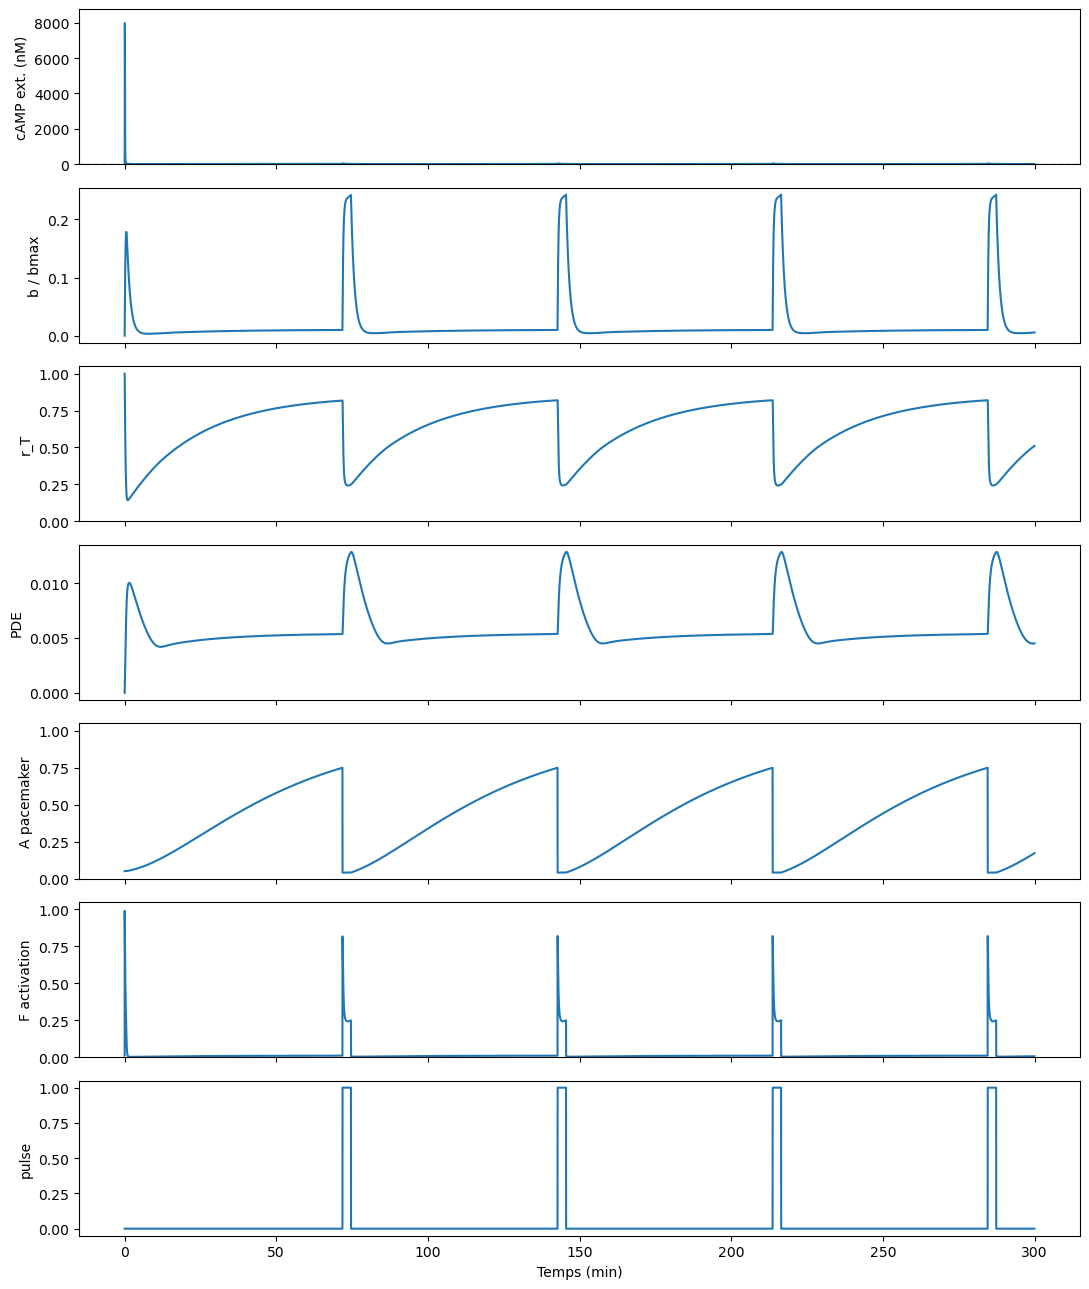

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Test 0D : oscillateur cAMP minimal
# =========================
# Objectif : obtenir une cellule pionnière qui pulse toute seule.
# Le modèle ajoute une variable lente de récupération interne, A,
# qui représente l'état pacemaker/famine de la cellule.

TIME_SIMU = 300.0       # minutes
dt = 0.001              # minutes
n_steps = int(TIME_SIMU / dt)

# Dégradation extracellulaire basale
J = 0.25
k_PDE = 2e4

# Récepteurs actifs / désensibilisation
F1_base = 3.0
F2_base = 0.035
N_HILL = 4
K_h = 3e-8              # 30 nM

# cAMP intracellulaire b
q_s = 7e-6
k_t = 0.9
b_max = q_s / k_t

# Sécrétion du cAMP extracellulaire
K_relay = 5.0e-2

# PDE / RegA
PDE_threshold = 3e-8
hill_n_PDE = 2
PDE_rate = 0.015
PDE_decay = 0.12

# Inhibition de la sécrétion par la PDE
# Valeur volontairement un peu plus haute pour laisser le pulse de cAMP
# dépasser le seuil d'activation des récepteurs avant que la PDE ne bloque tout.
PDE_inhibition_threshold = 2e-4

# Variable pacemaker lente
# A représente l'état interne de famine / maturité oscillatoire.
# Quand A dépasse A_trigger, la cellule déclenche un pulse autonome.
A = 0.05
A_recovery_rate = 0.030
A_min = 0.02
A_max = 1.0
A_trigger = 0.75
A_reset = 0.04

# Pulse autonome de la cellule pionnière
pulse_active = False
pulse_timer = 0.0
pulse_duration = 2.8       # minutes
pulse_strength = 1.0

# Petite activité basale de pionnière
f0 = 0.01

# =========================
# Conditions initiales
# =========================

c = 0.0       # cAMP extracellulaire
b = 0.0       # cAMP intracellulaire
r_T = 1.0     # fraction de récepteurs actifs
PDE = 0.0

# Petite amorce initiale, juste pour éviter un système parfaitement nul.
c += 1e-9

# =========================
# Traces
# =========================

times = np.zeros(n_steps)
c_trace = np.zeros(n_steps)
b_trace = np.zeros(n_steps)
r_trace = np.zeros(n_steps)
pde_trace = np.zeros(n_steps)
A_trace = np.zeros(n_steps)
F_trace = np.zeros(n_steps)
pulse_trace = np.zeros(n_steps)

# =========================
# Simulation 0D
# =========================

for i in range(n_steps):
    t = i * dt

    c_pos = max(c, 0.0)

    hill_c = c_pos**N_HILL / (K_h**N_HILL + c_pos**N_HILL + 1e-60)

    # Déclenchement autonome d'une cellule pionnière.
    # Tant que la cellule est sensible et que le cAMP externe est bas,
    # A remonte. Quand A dépasse un seuil, la cellule pulse.
    if (not pulse_active) and (A >= A_trigger) and (r_T > 0.8) and (hill_c < 0.2):
        pulse_active = True
        pulse_timer = pulse_duration
        A = A_reset

    if pulse_active:
        pacemaker_drive = pulse_strength
        pulse_timer -= dt
        if pulse_timer <= 0.0:
            pulse_active = False
            pulse_timer = 0.0
    else:
        pacemaker_drive = 0.0

    # Activation effective :
    # - f0 donne une très faible activité basale
    # - hill_c donne le relais induit par le cAMP externe
    # - pacemaker_drive donne le pulse autonome de la cellule pionnière
    activation = f0 + pacemaker_drive + (1.0 - f0) * hill_c
    activation = min(activation, 1.0)

    F_val = r_T * activation

    # Désensibilisation rapide quand le cAMP externe est haut
    f1_eff = F1_base * hill_c

    # PDE : production en réponse au cAMP externe
    pde_prod = PDE_rate * c_pos**hill_n_PDE / (
        PDE_threshold**hill_n_PDE + c_pos**hill_n_PDE + 1e-60
    )

    # Inhibition de la sécrétion quand la PDE accumulée est forte
    inhibition = 1.0 / (1.0 + (PDE / PDE_inhibition_threshold)**2)

    # Production / dégradation extracellulaire
    camp_prod = K_relay * (b / b_max) * inhibition
    camp_deg = J * c + k_PDE * PDE * c

    dc = camp_prod - camp_deg
    db = q_s * F_val - k_t * b
    dr = -f1_eff * r_T + F2_base * (1.0 - r_T)
    dPDE = pde_prod - PDE_decay * PDE

    # Variable pacemaker lente :
    # elle récupère seulement quand la cellule est sensible
    # et quand le cAMP externe est suffisamment bas.
    if pulse_active:
        dA = 0.0
    else:
        recovery_drive = r_T * (1.0 - hill_c)
        dA = A_recovery_rate * recovery_drive * (A_max - A)

    c += dc * dt
    b += db * dt
    r_T += dr * dt
    PDE += dPDE * dt
    A += dA * dt

    c = max(c, 0.0)
    b = max(b, 0.0)
    r_T = min(max(r_T, 0.0), 1.0)
    PDE = max(PDE, 0.0)
    A = min(max(A, A_min), A_max)

    times[i] = t
    c_trace[i] = c
    b_trace[i] = b / b_max
    r_trace[i] = r_T
    pde_trace[i] = PDE
    A_trace[i] = A
    F_trace[i] = F_val
    pulse_trace[i] = 1.0 if pulse_active else 0.0

# =========================
# Affichage
# =========================

fig, axes = plt.subplots(7, 1, figsize=(11, 13), sharex=True)

axes[0].plot(times, c_trace * 1e9)
axes[0].axhline(K_h * 1e9, linestyle="--", linewidth=1)
axes[0].set_ylabel("cAMP ext. (nM)")
axes[0].set_ylim(0, max(100, np.nanmax(c_trace * 1e9) * 1.1))

axes[1].plot(times, b_trace)
axes[1].set_ylabel("b / bmax")

axes[2].plot(times, r_trace)
axes[2].set_ylabel("r_T")
axes[2].set_ylim(0.0, 1.05)

axes[3].plot(times, pde_trace)
axes[3].set_ylabel("PDE")

axes[4].plot(times, A_trace)
axes[4].set_ylabel("A pacemaker")
axes[4].set_ylim(0, 1.05)

axes[5].plot(times, F_trace)
axes[5].set_ylabel("F activation")
axes[5].set_ylim(0, 1.05)

axes[6].plot(times, pulse_trace)
axes[6].set_ylabel("pulse")
axes[6].set_xlabel("Temps (min)")
axes[6].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

cAMP max = 1938.10 nM
cAMP max après 20 min = 32.88 nM
r_T min après 20 min = 0.442


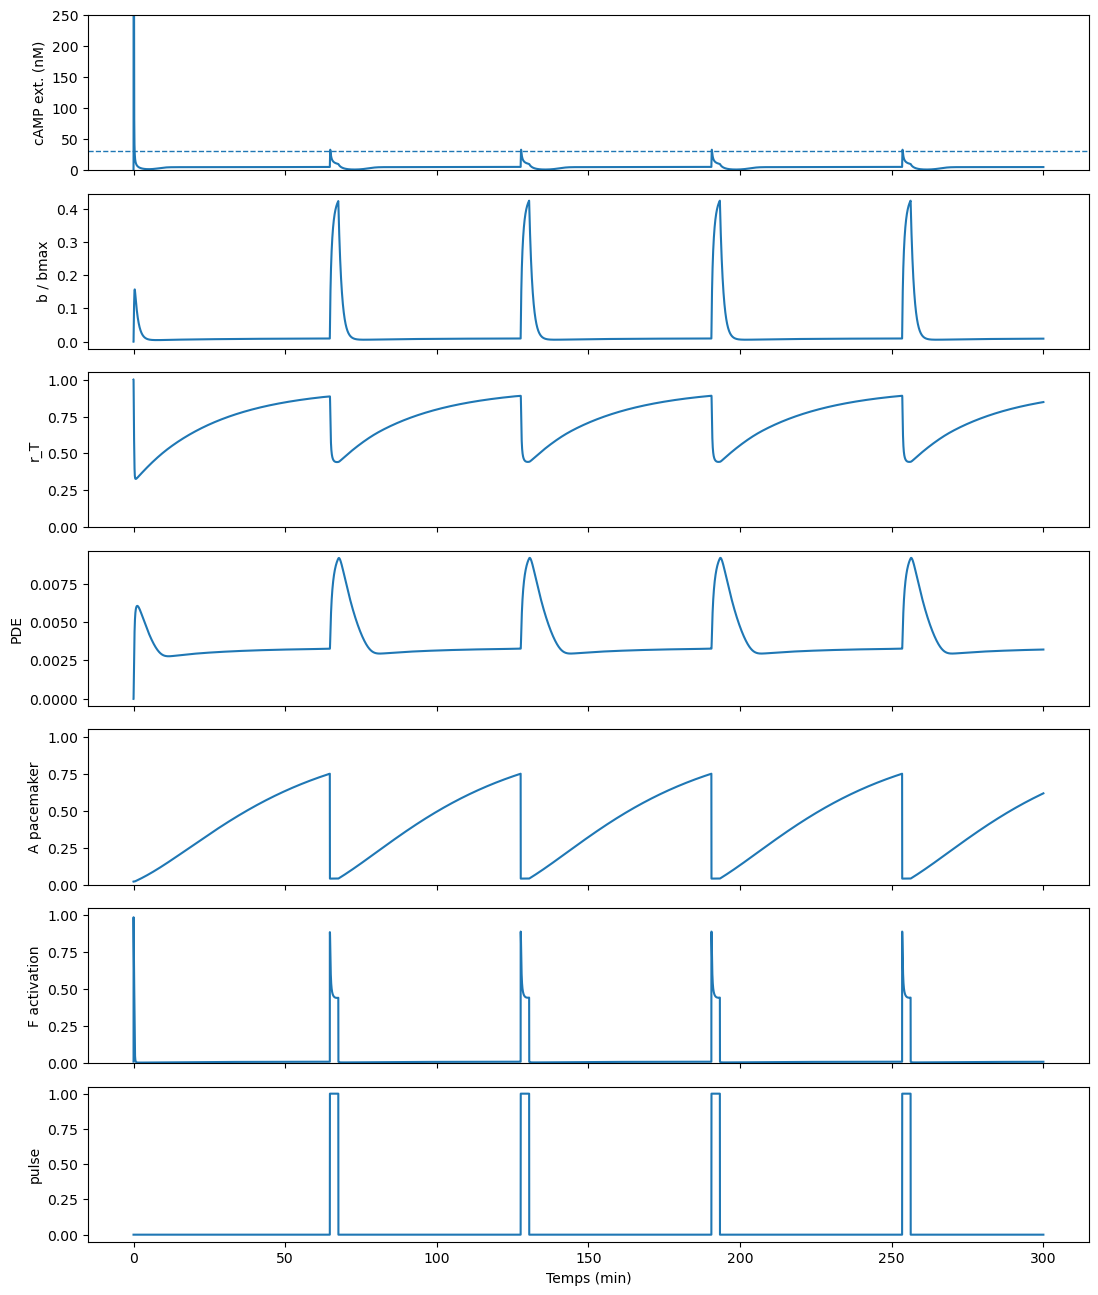

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Test 0D : oscillateur cAMP minimal
# =========================
# Objectif : obtenir une cellule pionnière qui pulse toute seule.
# Le modèle ajoute une variable lente de récupération interne, A,
# qui représente l'état pacemaker/famine de la cellule.

TIME_SIMU = 300.0       # minutes
dt = 0.001              # minutes
n_steps = int(TIME_SIMU / dt)

# Dégradation extracellulaire basale
J = 0.25
k_PDE = 2e4

# Récepteurs actifs / désensibilisation
F1_base = 3.0
F2_base = 0.035
N_HILL = 4
K_h = 3e-8              # 30 nM

# cAMP intracellulaire b
q_s = 7e-6
k_t = 0.9
b_max = q_s / k_t

# Sécrétion du cAMP extracellulaire
K_relay = 2.5e-2

# PDE / RegA
PDE_threshold = 3e-8
hill_n_PDE = 2
PDE_rate = 0.015
PDE_decay = 0.12

# Inhibition de la sécrétion par la PDE
# Valeur volontairement un peu plus haute pour laisser le pulse de cAMP
# dépasser le seuil d'activation des récepteurs avant que la PDE ne bloque tout.
PDE_inhibition_threshold = 1.2e-4

# Variable pacemaker lente
# A représente l'état interne de famine / maturité oscillatoire.
# Quand A dépasse A_trigger, la cellule déclenche un pulse autonome.
A = 0.02
A_recovery_rate = 0.030
A_min = 0.02
A_max = 1.0
A_trigger = 0.75
A_reset = 0.04

# Pulse autonome de la cellule pionnière
pulse_active = False
pulse_timer = 0.0
pulse_duration = 2.8       # minutes
pulse_strength = 1.0

# Petite activité basale de pionnière
f0 = 0.01

# =========================
# Conditions initiales
# =========================

c = 0.0       # cAMP extracellulaire
b = 0.0       # cAMP intracellulaire
r_T = 1.0     # fraction de récepteurs actifs
PDE = 0.0

# Pas d'amorce externe : la première émission vient uniquement du pacemaker.
# Cela évite un pic artificiel au tout début de la simulation.
c += 0.0

# =========================
# Traces
# =========================

times = np.zeros(n_steps)
c_trace = np.zeros(n_steps)
b_trace = np.zeros(n_steps)
r_trace = np.zeros(n_steps)
pde_trace = np.zeros(n_steps)
A_trace = np.zeros(n_steps)
F_trace = np.zeros(n_steps)
pulse_trace = np.zeros(n_steps)

# =========================
# Simulation 0D
# =========================

for i in range(n_steps):
    t = i * dt

    c_pos = max(c, 0.0)

    hill_c = c_pos**N_HILL / (K_h**N_HILL + c_pos**N_HILL + 1e-60)

    # Déclenchement autonome d'une cellule pionnière.
    # Tant que la cellule est sensible et que le cAMP externe est bas,
    # A remonte. Quand A dépasse un seuil, la cellule pulse.
    if (not pulse_active) and (A >= A_trigger) and (r_T > 0.8) and (hill_c < 0.2):
        pulse_active = True
        pulse_timer = pulse_duration
        A = A_reset

    if pulse_active:
        pacemaker_drive = pulse_strength
        pulse_timer -= dt
        if pulse_timer <= 0.0:
            pulse_active = False
            pulse_timer = 0.0
    else:
        pacemaker_drive = 0.0

    # Activation effective :
    # - f0 donne une très faible activité basale
    # - hill_c donne le relais induit par le cAMP externe
    # - pacemaker_drive donne le pulse autonome de la cellule pionnière
    activation = f0 + pacemaker_drive + (1.0 - f0) * hill_c
    activation = min(activation, 1.0)

    F_val = r_T * activation

    # Désensibilisation rapide quand le cAMP externe est haut
    f1_eff = F1_base * hill_c

    # PDE : production en réponse au cAMP externe
    pde_prod = PDE_rate * c_pos**hill_n_PDE / (
        PDE_threshold**hill_n_PDE + c_pos**hill_n_PDE + 1e-60
    )

    # Inhibition de la sécrétion quand la PDE accumulée est forte
    inhibition = 1.0 / (1.0 + (PDE / PDE_inhibition_threshold)**2)

    # Production / dégradation extracellulaire
    camp_prod = K_relay * (b / b_max) * inhibition
    camp_deg = J * c + k_PDE * PDE * c

    dc = camp_prod - camp_deg
    db = q_s * F_val - k_t * b
    dr = -f1_eff * r_T + F2_base * (1.0 - r_T)
    dPDE = pde_prod - PDE_decay * PDE

    # Variable pacemaker lente :
    # elle récupère seulement quand la cellule est sensible
    # et quand le cAMP externe est suffisamment bas.
    if pulse_active:
        dA = 0.0
    else:
        recovery_drive = r_T * (1.0 - hill_c)
        dA = A_recovery_rate * recovery_drive * (A_max - A)

    c += dc * dt
    b += db * dt
    r_T += dr * dt
    PDE += dPDE * dt
    A += dA * dt

    c = max(c, 0.0)
    b = max(b, 0.0)
    r_T = min(max(r_T, 0.0), 1.0)
    PDE = max(PDE, 0.0)
    A = min(max(A, A_min), A_max)

    times[i] = t
    c_trace[i] = c
    b_trace[i] = b / b_max
    r_trace[i] = r_T
    pde_trace[i] = PDE
    A_trace[i] = A
    F_trace[i] = F_val
    pulse_trace[i] = 1.0 if pulse_active else 0.0

# =========================
# Affichage
# =========================

fig, axes = plt.subplots(7, 1, figsize=(11, 13), sharex=True)

axes[0].plot(times, c_trace * 1e9)
axes[0].axhline(K_h * 1e9, linestyle="--", linewidth=1)
axes[0].set_ylabel("cAMP ext. (nM)")
# On limite l'affichage pour voir les pulses réguliers, même si un transitoire existe.
axes[0].set_ylim(0, 250)

axes[1].plot(times, b_trace)
axes[1].set_ylabel("b / bmax")

axes[2].plot(times, r_trace)
axes[2].set_ylabel("r_T")
axes[2].set_ylim(0.0, 1.05)

axes[3].plot(times, pde_trace)
axes[3].set_ylabel("PDE")

axes[4].plot(times, A_trace)
axes[4].set_ylabel("A pacemaker")
axes[4].set_ylim(0, 1.05)

axes[5].plot(times, F_trace)
axes[5].set_ylabel("F activation")
axes[5].set_ylim(0, 1.05)

axes[6].plot(times, pulse_trace)
axes[6].set_ylabel("pulse")
axes[6].set_xlabel("Temps (min)")
axes[6].set_ylim(-0.05, 1.05)

print(f"cAMP max = {np.nanmax(c_trace * 1e9):.2f} nM")
print(f"cAMP max après 20 min = {np.nanmax(c_trace[times > 20] * 1e9):.2f} nM")
print(f"r_T min après 20 min = {np.nanmin(r_trace[times > 20]):.3f}")

plt.tight_layout()
plt.show()

cAMP total max = 2085.19 nM
cAMP relais max = 2025.19 nM
b/bmax max = 0.179
r_T min = 0.014
F activation max = 0.988


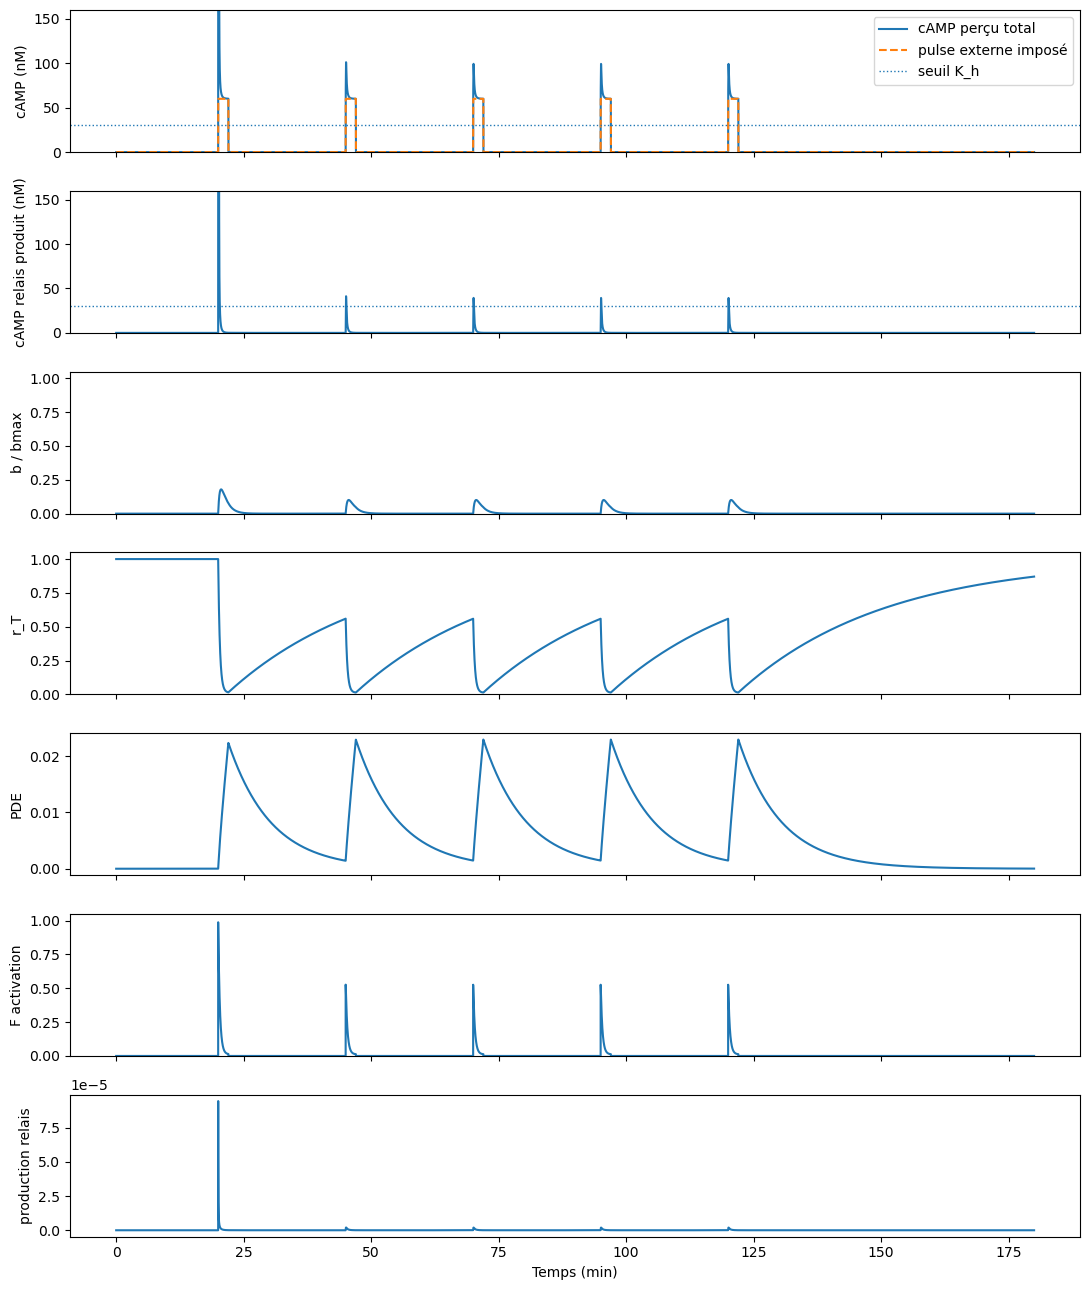

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Test 0D : cellule relais Dictyostelium
# ============================================================
# Objectif : tester une cellule NON pionnière.
# Elle ne doit pas osciller toute seule.
# Elle reçoit un ou plusieurs pulses externes de cAMP.
# Elle doit répondre par :
#   cAMP externe imposé -> activation -> b intracellulaire -> sécrétion relais
#   puis désensibilisation r_T -> phase réfractaire -> récupération.

TIME_SIMU = 180.0       # minutes
dt = 0.001              # minutes
n_steps = int(TIME_SIMU / dt)

# =========================
# Paramètres biochimiques
# =========================

# Dégradation extracellulaire basale
J = 0.25
k_PDE = 2e4

# Récepteurs actifs / désensibilisation
F1_base = 3.0
F2_base = 0.035
N_HILL = 4
K_h = 3e-8              # 30 nM

# cAMP intracellulaire b
q_s = 7e-6
k_t = 0.9
b_max = q_s / k_t

# Sécrétion relais du cAMP extracellulaire
K_relay = 2.5e-2

# PDE / RegA
PDE_threshold = 3e-8
hill_n_PDE = 2
PDE_rate = 0.015
PDE_decay = 0.12

# Inhibition de la sécrétion par la PDE
PDE_inhibition_threshold = 1.2e-4

# Pas de pacemaker dans une cellule relais
f0 = 0.0

# =========================
# Pulses externes imposés
# =========================
# Ici, on simule le passage d'une onde de cAMP venant d'une cellule voisine.
# Chaque pulse externe ajoute du cAMP dans le milieu pendant une courte durée.

external_pulses = [
    # (temps_debut_min, durée_min, amplitude_nM)
    (20.0, 2.0, 60.0),
    (45.0, 2.0, 60.0),
    (70.0, 2.0, 60.0),
    (95.0, 2.0, 60.0),
    (120.0, 2.0, 60.0),
]

# =========================
# Conditions initiales
# =========================

c = 0.0       # cAMP extracellulaire local produit/retenu dans le système
b = 0.0       # cAMP intracellulaire
r_T = 1.0     # fraction de récepteurs actifs
PDE = 0.0

# =========================
# Traces
# =========================

times = np.zeros(n_steps)
c_total_trace = np.zeros(n_steps)
c_internal_trace = np.zeros(n_steps)
c_ext_input_trace = np.zeros(n_steps)
b_trace = np.zeros(n_steps)
r_trace = np.zeros(n_steps)
pde_trace = np.zeros(n_steps)
F_trace = np.zeros(n_steps)
relay_prod_trace = np.zeros(n_steps)

# =========================
# Simulation 0D cellule relais
# =========================

for i in range(n_steps):
    t = i * dt

    # Signal externe imposé par les cellules voisines.
    c_ext_input = 0.0
    for t_start, duration, amp_nM in external_pulses:
        if t_start <= t < t_start + duration:
            c_ext_input += amp_nM * 1e-9

    # La cellule perçoit le cAMP local qu'elle produit + le cAMP externe imposé.
    c_total = max(c + c_ext_input, 0.0)

    hill_c = c_total**N_HILL / (K_h**N_HILL + c_total**N_HILL + 1e-60)

    # Activation de la cellule relais.
    # Ici pas de pacemaker : f0 = 0.
    # L'activation vient uniquement du cAMP externe/local.
    activation = f0 + (1.0 - f0) * hill_c
    activation = min(activation, 1.0)

    F_val = r_T * activation

    # Désensibilisation rapide quand le cAMP perçu est haut.
    f1_eff = F1_base * hill_c

    # PDE produite en réponse au cAMP perçu.
    pde_prod = PDE_rate * c_total**hill_n_PDE / (
        PDE_threshold**hill_n_PDE + c_total**hill_n_PDE + 1e-60
    )

    # Inhibition de la sécrétion quand la PDE accumulée est forte.
    inhibition = 1.0 / (1.0 + (PDE / PDE_inhibition_threshold)**2)

    # Production relais : la cellule sécrète du cAMP en réponse au stimulus.
    relay_prod = K_relay * (b / b_max) * inhibition

    # Dégradation du cAMP produit localement.
    # Le pulse externe imposé n'est pas intégré à c : il représente une onde qui passe.
    camp_deg = J * c + k_PDE * PDE * c

    dc = relay_prod - camp_deg
    db = q_s * F_val - k_t * b
    dr = -f1_eff * r_T + F2_base * (1.0 - r_T)
    dPDE = pde_prod - PDE_decay * PDE

    c += dc * dt
    b += db * dt
    r_T += dr * dt
    PDE += dPDE * dt

    c = max(c, 0.0)
    b = max(b, 0.0)
    r_T = min(max(r_T, 0.0), 1.0)
    PDE = max(PDE, 0.0)

    times[i] = t
    c_total_trace[i] = c_total
    c_internal_trace[i] = c
    c_ext_input_trace[i] = c_ext_input
    b_trace[i] = b / b_max
    r_trace[i] = r_T
    pde_trace[i] = PDE
    F_trace[i] = F_val
    relay_prod_trace[i] = relay_prod

# =========================
# Affichage
# =========================

fig, axes = plt.subplots(7, 1, figsize=(11, 13), sharex=True)

axes[0].plot(times, c_total_trace * 1e9, label="cAMP perçu total")
axes[0].plot(times, c_ext_input_trace * 1e9, linestyle="--", label="pulse externe imposé")
axes[0].axhline(K_h * 1e9, linestyle=":", linewidth=1, label="seuil K_h")
axes[0].set_ylabel("cAMP (nM)")
axes[0].set_ylim(0, 160)
axes[0].legend(loc="upper right")

axes[1].plot(times, c_internal_trace * 1e9)
axes[1].axhline(K_h * 1e9, linestyle=":", linewidth=1)
axes[1].set_ylabel("cAMP relais produit (nM)")
axes[1].set_ylim(0, 160)

axes[2].plot(times, b_trace)
axes[2].set_ylabel("b / bmax")
axes[2].set_ylim(0, 1.05)

axes[3].plot(times, r_trace)
axes[3].set_ylabel("r_T")
axes[3].set_ylim(0, 1.05)

axes[4].plot(times, pde_trace)
axes[4].set_ylabel("PDE")

axes[5].plot(times, F_trace)
axes[5].set_ylabel("F activation")
axes[5].set_ylim(0, 1.05)

axes[6].plot(times, relay_prod_trace)
axes[6].set_ylabel("production relais")
axes[6].set_xlabel("Temps (min)")

print(f"cAMP total max = {np.nanmax(c_total_trace * 1e9):.2f} nM")
print(f"cAMP relais max = {np.nanmax(c_internal_trace * 1e9):.2f} nM")
print(f"b/bmax max = {np.nanmax(b_trace):.3f}")
print(f"r_T min = {np.nanmin(r_trace):.3f}")
print(f"F activation max = {np.nanmax(F_trace):.3f}")

plt.tight_layout()
plt.show()

cAMP total max = 18593.47 nM
cAMP relais max = 18533.47 nM
b/bmax max = 0.319
r_T min = 0.077
F activation max = 0.995


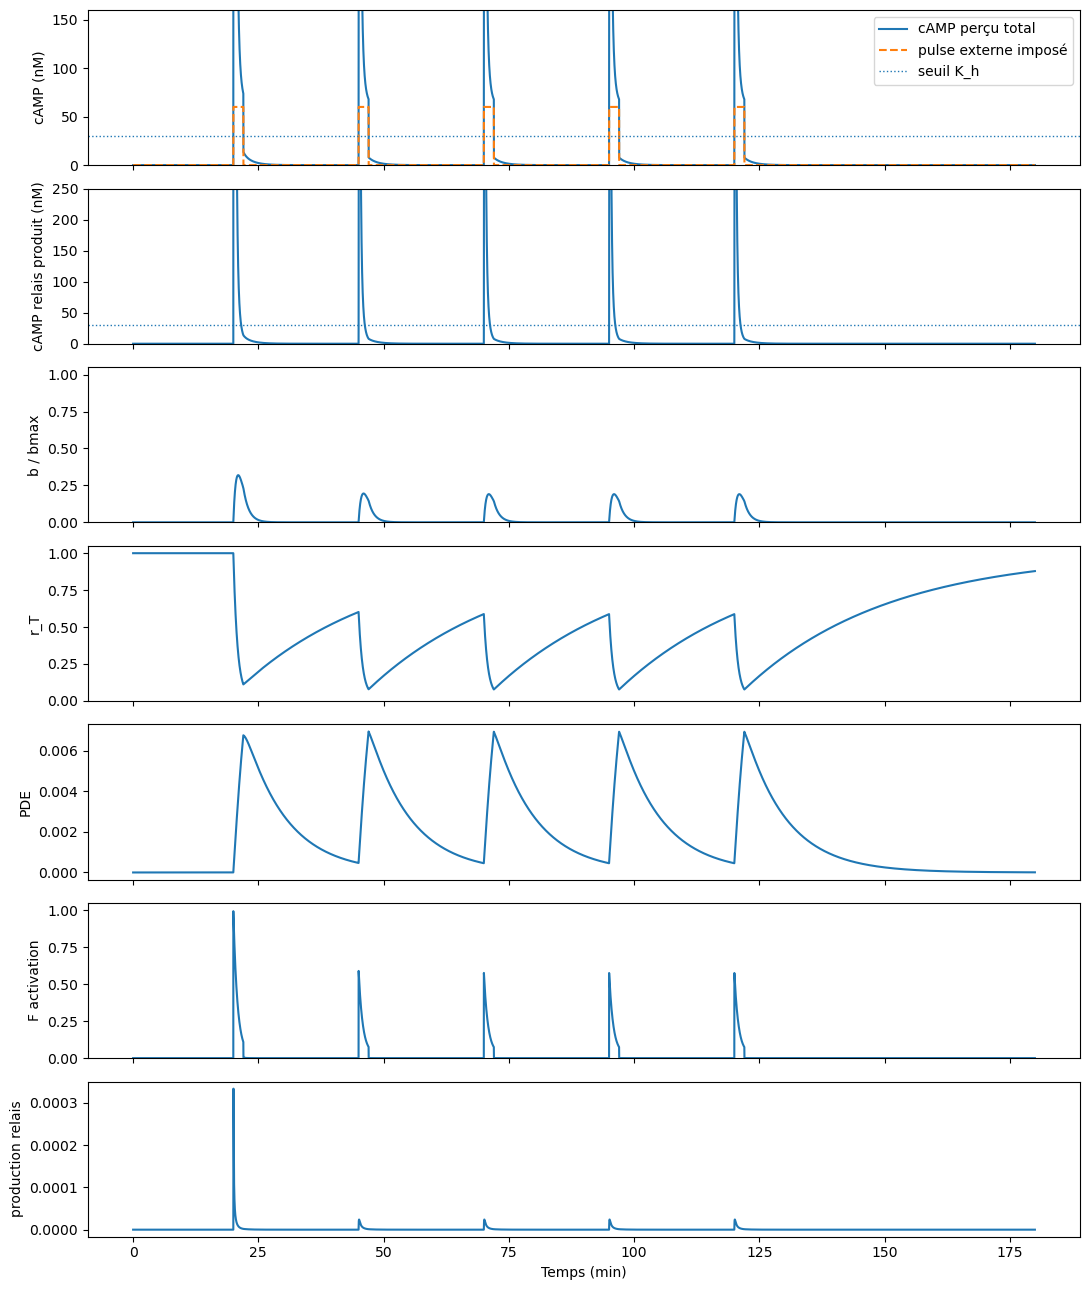

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Test 0D : cellule relais Dictyostelium
# ============================================================
# Objectif : tester une cellule NON pionnière.
# Elle ne doit pas osciller toute seule.
# Elle reçoit un ou plusieurs pulses externes de cAMP.
# Elle doit répondre par :
#   cAMP externe imposé -> activation -> b intracellulaire -> sécrétion relais
#   puis désensibilisation r_T -> phase réfractaire -> récupération.

TIME_SIMU = 180.0       # minutes
dt = 0.001              # minutes
n_steps = int(TIME_SIMU / dt)

# =========================
# Paramètres biochimiques
# =========================

# Dégradation extracellulaire basale
J = 0.25
k_PDE = 2e4

# Récepteurs actifs / désensibilisation
F1_base = 1.2
F2_base = 0.035
N_HILL = 4
K_h = 3e-8              # 30 nM

# cAMP intracellulaire b
q_s = 2.0e-5
k_t = 0.9
b_max = q_s / k_t

# Sécrétion relais du cAMP extracellulaire
K_relay = 2.5e-2

# PDE / RegA
PDE_threshold = 3e-8
hill_n_PDE = 2
PDE_rate = 0.004
PDE_decay = 0.12

# Inhibition de la sécrétion par la PDE
PDE_inhibition_threshold = 1.2e-4

# Pas de pacemaker dans une cellule relais
f0 = 0.0

# =========================
# Pulses externes imposés
# =========================
# Ici, on simule le passage d'une onde de cAMP venant d'une cellule voisine.
# Chaque pulse externe ajoute du cAMP dans le milieu pendant une courte durée.

external_pulses = [
    # (temps_debut_min, durée_min, amplitude_nM)
    (20.0, 2.0, 60.0),
    (45.0, 2.0, 60.0),
    (70.0, 2.0, 60.0),
    (95.0, 2.0, 60.0),
    (120.0, 2.0, 60.0),
]

# =========================
# Conditions initiales
# =========================

c = 0.0       # cAMP extracellulaire local produit/retenu dans le système
b = 0.0       # cAMP intracellulaire
r_T = 1.0     # fraction de récepteurs actifs
PDE = 0.0

# =========================
# Traces
# =========================

times = np.zeros(n_steps)
c_total_trace = np.zeros(n_steps)
c_internal_trace = np.zeros(n_steps)
c_ext_input_trace = np.zeros(n_steps)
b_trace = np.zeros(n_steps)
r_trace = np.zeros(n_steps)
pde_trace = np.zeros(n_steps)
F_trace = np.zeros(n_steps)
relay_prod_trace = np.zeros(n_steps)

# =========================
# Simulation 0D cellule relais
# =========================

for i in range(n_steps):
    t = i * dt

    # Signal externe imposé par les cellules voisines.
    c_ext_input = 0.0
    for t_start, duration, amp_nM in external_pulses:
        if t_start <= t < t_start + duration:
            c_ext_input += amp_nM * 1e-9

    # La cellule perçoit le cAMP local qu'elle produit + le cAMP externe imposé.
    c_total = max(c + c_ext_input, 0.0)

    hill_c = c_total**N_HILL / (K_h**N_HILL + c_total**N_HILL + 1e-60)

    # Activation de la cellule relais.
    # Ici pas de pacemaker : f0 = 0.
    # L'activation vient uniquement du cAMP externe/local.
    activation = f0 + (1.0 - f0) * hill_c
    activation = min(activation, 1.0)

    F_val = r_T * activation

    # Désensibilisation rapide quand le cAMP perçu est haut.
    f1_eff = F1_base * hill_c

    # PDE produite en réponse au cAMP perçu.
    pde_prod = PDE_rate * c_total**hill_n_PDE / (
        PDE_threshold**hill_n_PDE + c_total**hill_n_PDE + 1e-60
    )

    # Inhibition de la sécrétion quand la PDE accumulée est forte.
    inhibition = 1.0 / (1.0 + (PDE / PDE_inhibition_threshold)**2)

    # Production relais : la cellule sécrète du cAMP en réponse au stimulus.
    relay_prod = K_relay * (b / b_max) * inhibition

    # Dégradation du cAMP produit localement.
    # Le pulse externe imposé n'est pas intégré à c : il représente une onde qui passe.
    camp_deg = J * c + k_PDE * PDE * c

    dc = relay_prod - camp_deg
    db = q_s * F_val - k_t * b
    dr = -f1_eff * r_T + F2_base * (1.0 - r_T)
    dPDE = pde_prod - PDE_decay * PDE

    c += dc * dt
    b += db * dt
    r_T += dr * dt
    PDE += dPDE * dt

    c = max(c, 0.0)
    b = max(b, 0.0)
    r_T = min(max(r_T, 0.0), 1.0)
    PDE = max(PDE, 0.0)

    times[i] = t
    c_total_trace[i] = c_total
    c_internal_trace[i] = c
    c_ext_input_trace[i] = c_ext_input
    b_trace[i] = b / b_max
    r_trace[i] = r_T
    pde_trace[i] = PDE
    F_trace[i] = F_val
    relay_prod_trace[i] = relay_prod

# =========================
# Affichage
# =========================

fig, axes = plt.subplots(7, 1, figsize=(11, 13), sharex=True)

axes[0].plot(times, c_total_trace * 1e9, label="cAMP perçu total")
axes[0].plot(times, c_ext_input_trace * 1e9, linestyle="--", label="pulse externe imposé")
axes[0].axhline(K_h * 1e9, linestyle=":", linewidth=1, label="seuil K_h")
axes[0].set_ylabel("cAMP (nM)")
axes[0].set_ylim(0, 160)
axes[0].legend(loc="upper right")

axes[1].plot(times, c_internal_trace * 1e9)
axes[1].axhline(K_h * 1e9, linestyle=":", linewidth=1)
axes[1].set_ylabel("cAMP relais produit (nM)")
axes[1].set_ylim(0, 250)

axes[2].plot(times, b_trace)
axes[2].set_ylabel("b / bmax")
axes[2].set_ylim(0, 1.05)

axes[3].plot(times, r_trace)
axes[3].set_ylabel("r_T")
axes[3].set_ylim(0, 1.05)

axes[4].plot(times, pde_trace)
axes[4].set_ylabel("PDE")

axes[5].plot(times, F_trace)
axes[5].set_ylabel("F activation")
axes[5].set_ylim(0, 1.05)

axes[6].plot(times, relay_prod_trace)
axes[6].set_ylabel("production relais")
axes[6].set_xlabel("Temps (min)")

print(f"cAMP total max = {np.nanmax(c_total_trace * 1e9):.2f} nM")
print(f"cAMP relais max = {np.nanmax(c_internal_trace * 1e9):.2f} nM")
print(f"b/bmax max = {np.nanmax(b_trace):.3f}")
print(f"r_T min = {np.nanmin(r_trace):.3f}")
print(f"F activation max = {np.nanmax(F_trace):.3f}")

plt.tight_layout()
plt.show()

cAMP total max = 8995.91 nM
cAMP relais max = 8935.91 nM
b/bmax max = 0.321
r_T min = 0.109
F activation max = 0.993


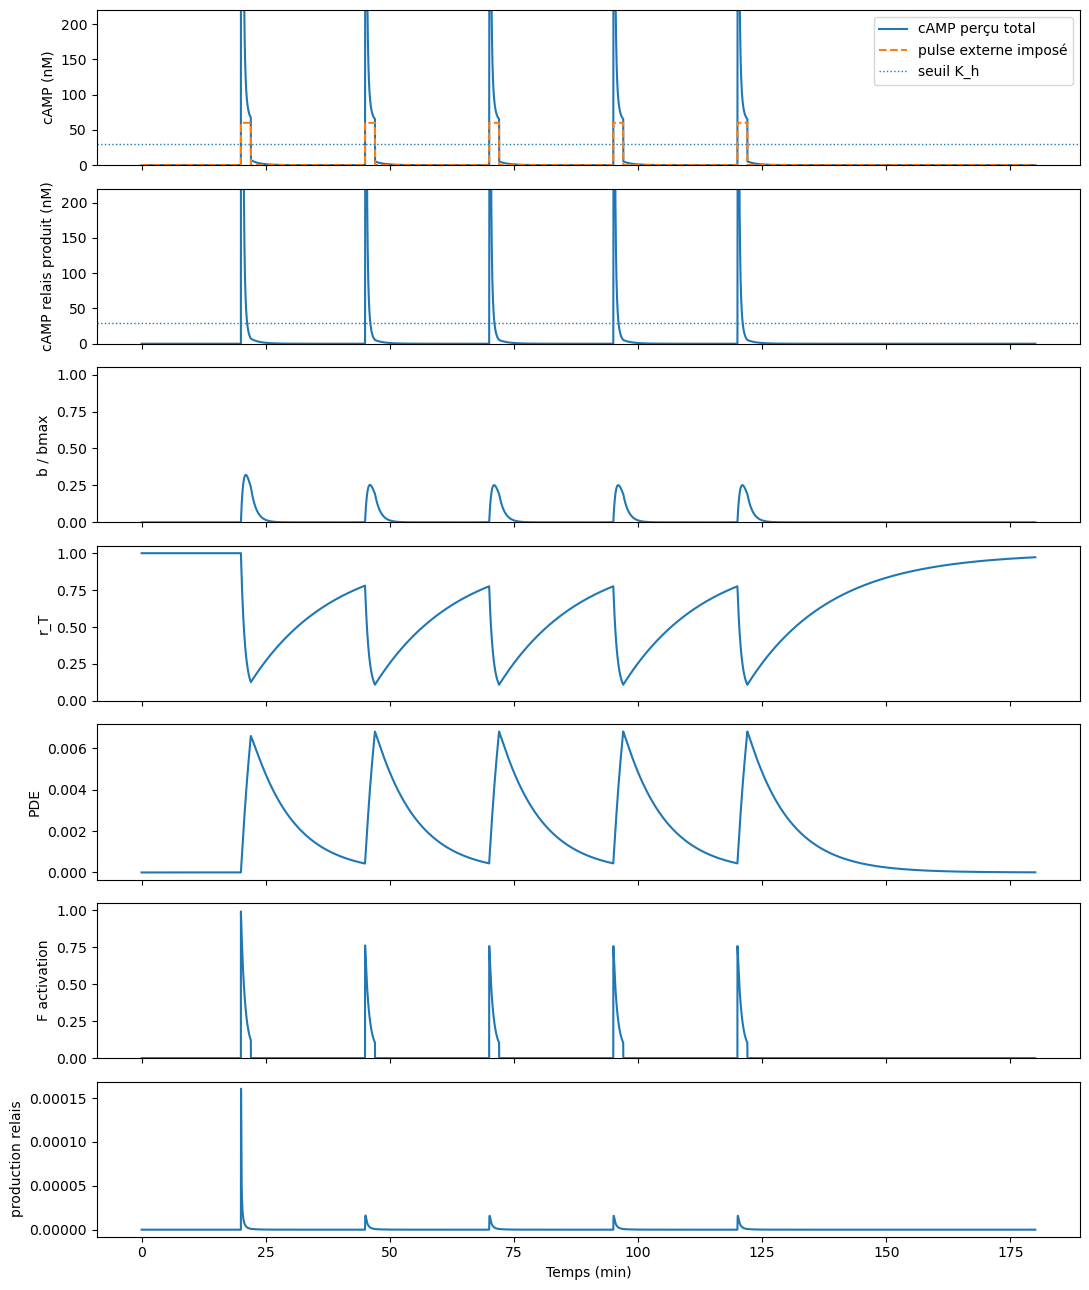

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Test 0D : cellule relais Dictyostelium
# ============================================================
# Objectif : tester une cellule NON pionnière.
# Elle ne doit pas osciller toute seule.
# Elle reçoit un ou plusieurs pulses externes de cAMP.
# Elle doit répondre par :
#   cAMP externe imposé -> activation -> b intracellulaire -> sécrétion relais
#   puis désensibilisation r_T -> phase réfractaire -> récupération.

TIME_SIMU = 180.0       # minutes
dt = 0.001              # minutes
n_steps = int(TIME_SIMU / dt)

# =========================
# Paramètres biochimiques
# =========================

# Dégradation extracellulaire basale
J = 0.25
k_PDE = 2e4

# Récepteurs actifs / désensibilisation
F1_base = 1.2
F2_base = 0.06
N_HILL = 4
K_h = 3e-8              # 30 nM

# cAMP intracellulaire b
q_s = 2.0e-5
k_t = 0.9
b_max = q_s / k_t

# Sécrétion relais du cAMP extracellulaire
K_relay = 1.2e-2

# PDE / RegA
PDE_threshold = 3e-8
hill_n_PDE = 2
PDE_rate = 0.004
PDE_decay = 0.12

# Inhibition de la sécrétion par la PDE
PDE_inhibition_threshold = 1.2e-4

# Pas de pacemaker dans une cellule relais
f0 = 0.0

# =========================
# Pulses externes imposés
# =========================
# Ici, on simule le passage d'une onde de cAMP venant d'une cellule voisine.
# Chaque pulse externe ajoute du cAMP dans le milieu pendant une courte durée.

external_pulses = [
    # (temps_debut_min, durée_min, amplitude_nM)
    (20.0, 2.0, 60.0),
    (45.0, 2.0, 60.0),
    (70.0, 2.0, 60.0),
    (95.0, 2.0, 60.0),
    (120.0, 2.0, 60.0),
]

# =========================
# Conditions initiales
# =========================

c = 0.0       # cAMP extracellulaire local produit/retenu dans le système
b = 0.0       # cAMP intracellulaire
r_T = 1.0     # fraction de récepteurs actifs
PDE = 0.0

# =========================
# Traces
# =========================

times = np.zeros(n_steps)
c_total_trace = np.zeros(n_steps)
c_internal_trace = np.zeros(n_steps)
c_ext_input_trace = np.zeros(n_steps)
b_trace = np.zeros(n_steps)
r_trace = np.zeros(n_steps)
pde_trace = np.zeros(n_steps)
F_trace = np.zeros(n_steps)
relay_prod_trace = np.zeros(n_steps)

# =========================
# Simulation 0D cellule relais
# =========================

for i in range(n_steps):
    t = i * dt

    # Signal externe imposé par les cellules voisines.
    c_ext_input = 0.0
    for t_start, duration, amp_nM in external_pulses:
        if t_start <= t < t_start + duration:
            c_ext_input += amp_nM * 1e-9

    # La cellule perçoit le cAMP local qu'elle produit + le cAMP externe imposé.
    c_total = max(c + c_ext_input, 0.0)

    hill_c = c_total**N_HILL / (K_h**N_HILL + c_total**N_HILL + 1e-60)

    # Activation de la cellule relais.
    # Ici pas de pacemaker : f0 = 0.
    # L'activation vient uniquement du cAMP externe/local.
    activation = f0 + (1.0 - f0) * hill_c
    activation = min(activation, 1.0)

    F_val = r_T * activation

    # Désensibilisation rapide quand le cAMP perçu est haut.
    f1_eff = F1_base * hill_c

    # PDE produite en réponse au cAMP perçu.
    pde_prod = PDE_rate * c_total**hill_n_PDE / (
        PDE_threshold**hill_n_PDE + c_total**hill_n_PDE + 1e-60
    )

    # Inhibition de la sécrétion quand la PDE accumulée est forte.
    inhibition = 1.0 / (1.0 + (PDE / PDE_inhibition_threshold)**2)

    # Production relais : la cellule sécrète du cAMP en réponse au stimulus.
    relay_prod = K_relay * (b / b_max) * inhibition

    # Dégradation du cAMP produit localement.
    # Le pulse externe imposé n'est pas intégré à c : il représente une onde qui passe.
    camp_deg = J * c + k_PDE * PDE * c

    dc = relay_prod - camp_deg
    db = q_s * F_val - k_t * b
    dr = -f1_eff * r_T + F2_base * (1.0 - r_T)
    dPDE = pde_prod - PDE_decay * PDE

    c += dc * dt
    b += db * dt
    r_T += dr * dt
    PDE += dPDE * dt

    c = max(c, 0.0)
    b = max(b, 0.0)
    r_T = min(max(r_T, 0.0), 1.0)
    PDE = max(PDE, 0.0)

    times[i] = t
    c_total_trace[i] = c_total
    c_internal_trace[i] = c
    c_ext_input_trace[i] = c_ext_input
    b_trace[i] = b / b_max
    r_trace[i] = r_T
    pde_trace[i] = PDE
    F_trace[i] = F_val
    relay_prod_trace[i] = relay_prod

# =========================
# Affichage
# =========================

fig, axes = plt.subplots(7, 1, figsize=(11, 13), sharex=True)

axes[0].plot(times, c_total_trace * 1e9, label="cAMP perçu total")
axes[0].plot(times, c_ext_input_trace * 1e9, linestyle="--", label="pulse externe imposé")
axes[0].axhline(K_h * 1e9, linestyle=":", linewidth=1, label="seuil K_h")
axes[0].set_ylabel("cAMP (nM)")
axes[0].set_ylim(0, 220)
axes[0].legend(loc="upper right")

axes[1].plot(times, c_internal_trace * 1e9)
axes[1].axhline(K_h * 1e9, linestyle=":", linewidth=1)
axes[1].set_ylabel("cAMP relais produit (nM)")
axes[1].set_ylim(0, 220)

axes[2].plot(times, b_trace)
axes[2].set_ylabel("b / bmax")
axes[2].set_ylim(0, 1.05)

axes[3].plot(times, r_trace)
axes[3].set_ylabel("r_T")
axes[3].set_ylim(0, 1.05)

axes[4].plot(times, pde_trace)
axes[4].set_ylabel("PDE")

axes[5].plot(times, F_trace)
axes[5].set_ylabel("F activation")
axes[5].set_ylim(0, 1.05)

axes[6].plot(times, relay_prod_trace)
axes[6].set_ylabel("production relais")
axes[6].set_xlabel("Temps (min)")

print(f"cAMP total max = {np.nanmax(c_total_trace * 1e9):.2f} nM")
print(f"cAMP relais max = {np.nanmax(c_internal_trace * 1e9):.2f} nM")
print(f"b/bmax max = {np.nanmax(b_trace):.3f}")
print(f"r_T min = {np.nanmin(r_trace):.3f}")
print(f"F activation max = {np.nanmax(F_trace):.3f}")

plt.tight_layout()
plt.show()

cAMP total max = 1382.67 nM
cAMP relais max = 1322.67 nM
b/bmax max = 0.391
r_T min = 0.210
F activation max = 0.991


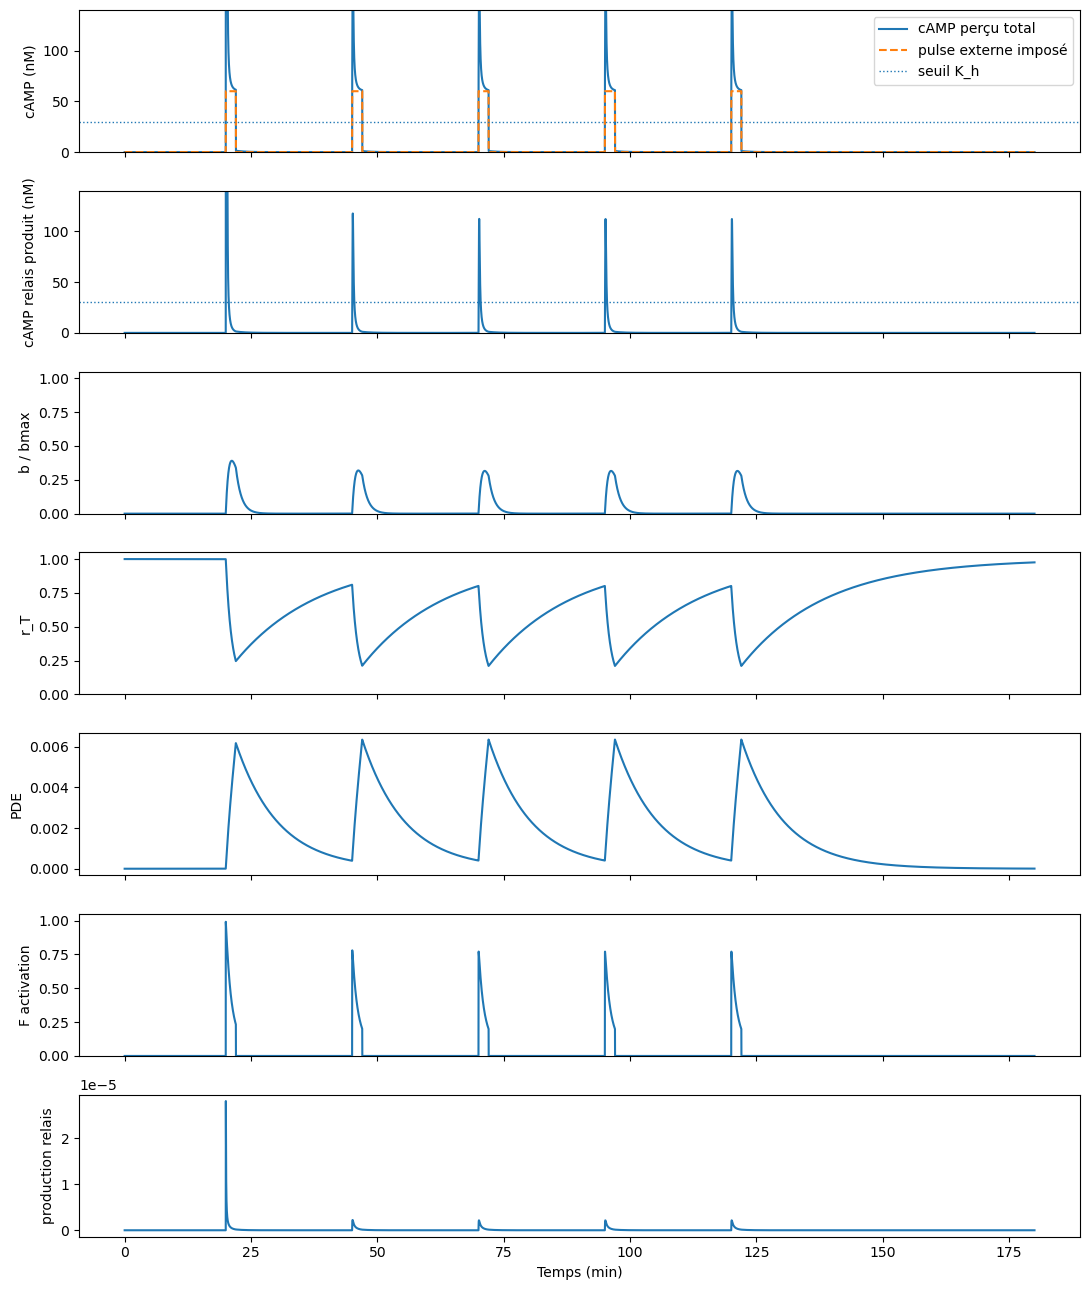

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Test 0D : cellule relais Dictyostelium
# ============================================================
# Objectif : tester une cellule NON pionnière.
# Elle ne doit pas osciller toute seule.
# Elle reçoit un ou plusieurs pulses externes de cAMP.
# Elle doit répondre par :
#   cAMP externe imposé -> activation -> b intracellulaire -> sécrétion relais
#   puis désensibilisation r_T -> phase réfractaire -> récupération.

TIME_SIMU = 180.0       # minutes
dt = 0.001              # minutes
n_steps = int(TIME_SIMU / dt)

# =========================
# Paramètres biochimiques
# =========================

# Dégradation extracellulaire basale
J = 0.25
k_PDE = 2e4

# Récepteurs actifs / désensibilisation
F1_base = 0.8
F2_base = 0.06
N_HILL = 4
K_h = 3e-8              # 30 nM

# cAMP intracellulaire b
q_s = 2.0e-5
k_t = 0.9
b_max = q_s / k_t

# Sécrétion relais du cAMP extracellulaire
K_relay = 3.0e-3

# PDE / RegA
PDE_threshold = 3e-8
hill_n_PDE = 2
PDE_rate = 0.004
PDE_decay = 0.12

# Inhibition de la sécrétion par la PDE
# Plus cette valeur est basse, plus la PDE coupe rapidement la production relayée.
PDE_inhibition_threshold = 8.0e-5

# Pas de pacemaker dans une cellule relais
f0 = 0.0

# =========================
# Pulses externes imposés
# =========================
# Ici, on simule le passage d'une onde de cAMP venant d'une cellule voisine.
# Chaque pulse externe ajoute du cAMP dans le milieu pendant une courte durée.

external_pulses = [
    # (temps_debut_min, durée_min, amplitude_nM)
    (20.0, 2.0, 60.0),
    (45.0, 2.0, 60.0),
    (70.0, 2.0, 60.0),
    (95.0, 2.0, 60.0),
    (120.0, 2.0, 60.0),
]

# =========================
# Conditions initiales
# =========================

c = 0.0       # cAMP extracellulaire local produit/retenu dans le système
b = 0.0       # cAMP intracellulaire
r_T = 1.0     # fraction de récepteurs actifs
PDE = 0.0

# =========================
# Traces
# =========================

times = np.zeros(n_steps)
c_total_trace = np.zeros(n_steps)
c_internal_trace = np.zeros(n_steps)
c_ext_input_trace = np.zeros(n_steps)
b_trace = np.zeros(n_steps)
r_trace = np.zeros(n_steps)
pde_trace = np.zeros(n_steps)
F_trace = np.zeros(n_steps)
relay_prod_trace = np.zeros(n_steps)

# =========================
# Simulation 0D cellule relais
# =========================

for i in range(n_steps):
    t = i * dt

    # Signal externe imposé par les cellules voisines.
    c_ext_input = 0.0
    for t_start, duration, amp_nM in external_pulses:
        if t_start <= t < t_start + duration:
            c_ext_input += amp_nM * 1e-9

    # La cellule perçoit le cAMP local qu'elle produit + le cAMP externe imposé.
    c_total = max(c + c_ext_input, 0.0)

    hill_c = c_total**N_HILL / (K_h**N_HILL + c_total**N_HILL + 1e-60)

    # Activation de la cellule relais.
    # Ici pas de pacemaker : f0 = 0.
    # L'activation vient uniquement du cAMP externe/local.
    activation = f0 + (1.0 - f0) * hill_c
    activation = min(activation, 1.0)

    F_val = r_T * activation

    # Désensibilisation rapide quand le cAMP perçu est haut.
    f1_eff = F1_base * hill_c

    # PDE produite en réponse au cAMP perçu.
    pde_prod = PDE_rate * c_total**hill_n_PDE / (
        PDE_threshold**hill_n_PDE + c_total**hill_n_PDE + 1e-60
    )

    # Inhibition de la sécrétion quand la PDE accumulée est forte.
    inhibition = 1.0 / (1.0 + (PDE / PDE_inhibition_threshold)**2)

    # Production relais : la cellule sécrète du cAMP en réponse au stimulus.
    relay_prod = K_relay * (b / b_max) * inhibition

    # Dégradation du cAMP produit localement.
    # Le pulse externe imposé n'est pas intégré à c : il représente une onde qui passe.
    camp_deg = J * c + k_PDE * PDE * c

    dc = relay_prod - camp_deg
    db = q_s * F_val - k_t * b
    dr = -f1_eff * r_T + F2_base * (1.0 - r_T)
    dPDE = pde_prod - PDE_decay * PDE

    c += dc * dt
    b += db * dt
    r_T += dr * dt
    PDE += dPDE * dt

    c = max(c, 0.0)
    b = max(b, 0.0)
    r_T = min(max(r_T, 0.0), 1.0)
    PDE = max(PDE, 0.0)

    times[i] = t
    c_total_trace[i] = c_total
    c_internal_trace[i] = c
    c_ext_input_trace[i] = c_ext_input
    b_trace[i] = b / b_max
    r_trace[i] = r_T
    pde_trace[i] = PDE
    F_trace[i] = F_val
    relay_prod_trace[i] = relay_prod

# =========================
# Affichage
# =========================

fig, axes = plt.subplots(7, 1, figsize=(11, 13), sharex=True)

axes[0].plot(times, c_total_trace * 1e9, label="cAMP perçu total")
axes[0].plot(times, c_ext_input_trace * 1e9, linestyle="--", label="pulse externe imposé")
axes[0].axhline(K_h * 1e9, linestyle=":", linewidth=1, label="seuil K_h")
axes[0].set_ylabel("cAMP (nM)")
axes[0].set_ylim(0, 140)
axes[0].legend(loc="upper right")

axes[1].plot(times, c_internal_trace * 1e9)
axes[1].axhline(K_h * 1e9, linestyle=":", linewidth=1)
axes[1].set_ylabel("cAMP relais produit (nM)")
axes[1].set_ylim(0, 140)

axes[2].plot(times, b_trace)
axes[2].set_ylabel("b / bmax")
axes[2].set_ylim(0, 1.05)

axes[3].plot(times, r_trace)
axes[3].set_ylabel("r_T")
axes[3].set_ylim(0, 1.05)

axes[4].plot(times, pde_trace)
axes[4].set_ylabel("PDE")

axes[5].plot(times, F_trace)
axes[5].set_ylabel("F activation")
axes[5].set_ylim(0, 1.05)

axes[6].plot(times, relay_prod_trace)
axes[6].set_ylabel("production relais")
axes[6].set_xlabel("Temps (min)")
# La production est un flux, pas une concentration : l'échelle automatique est plus lisible.

print(f"cAMP total max = {np.nanmax(c_total_trace * 1e9):.2f} nM")
print(f"cAMP relais max = {np.nanmax(c_internal_trace * 1e9):.2f} nM")
print(f"b/bmax max = {np.nanmax(b_trace):.3f}")
print(f"r_T min = {np.nanmin(r_trace):.3f}")
print(f"F activation max = {np.nanmax(F_trace):.3f}")

plt.tight_layout()
plt.show()

cAMP max global = 1245.39 nM
cellule 04 | cAMP max = 1245.39 nM | b/bmax max = 0.622 | r_T min = 0.595
cellule 10 | cAMP max = 1186.11 nM | b/bmax max = 0.313 | r_T min = 0.578
cellule 18 | cAMP max = 1169.13 nM | b/bmax max = 0.313 | r_T min = 0.578
cellule 30 | cAMP max = 1182.76 nM | b/bmax max = 0.313 | r_T min = 0.578


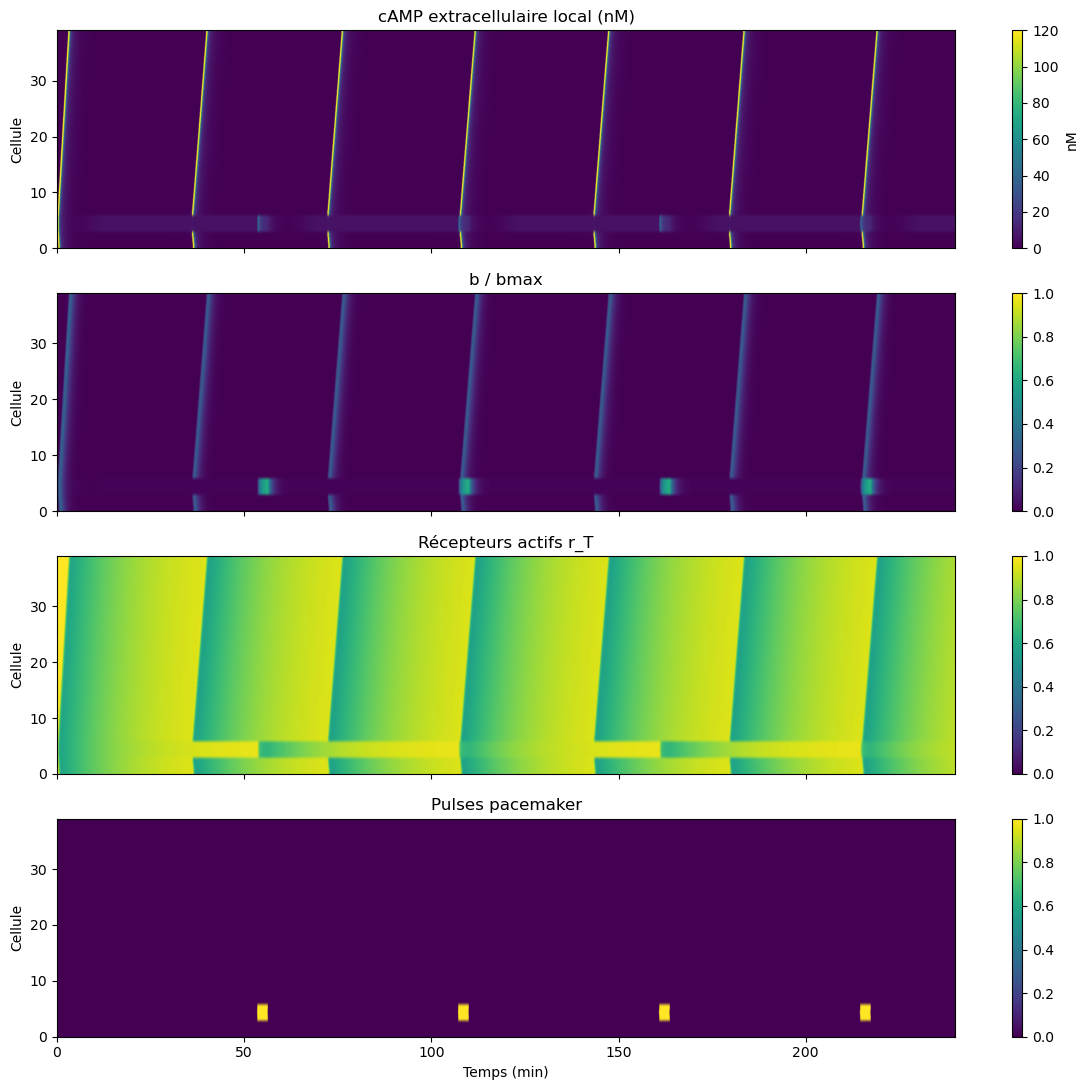

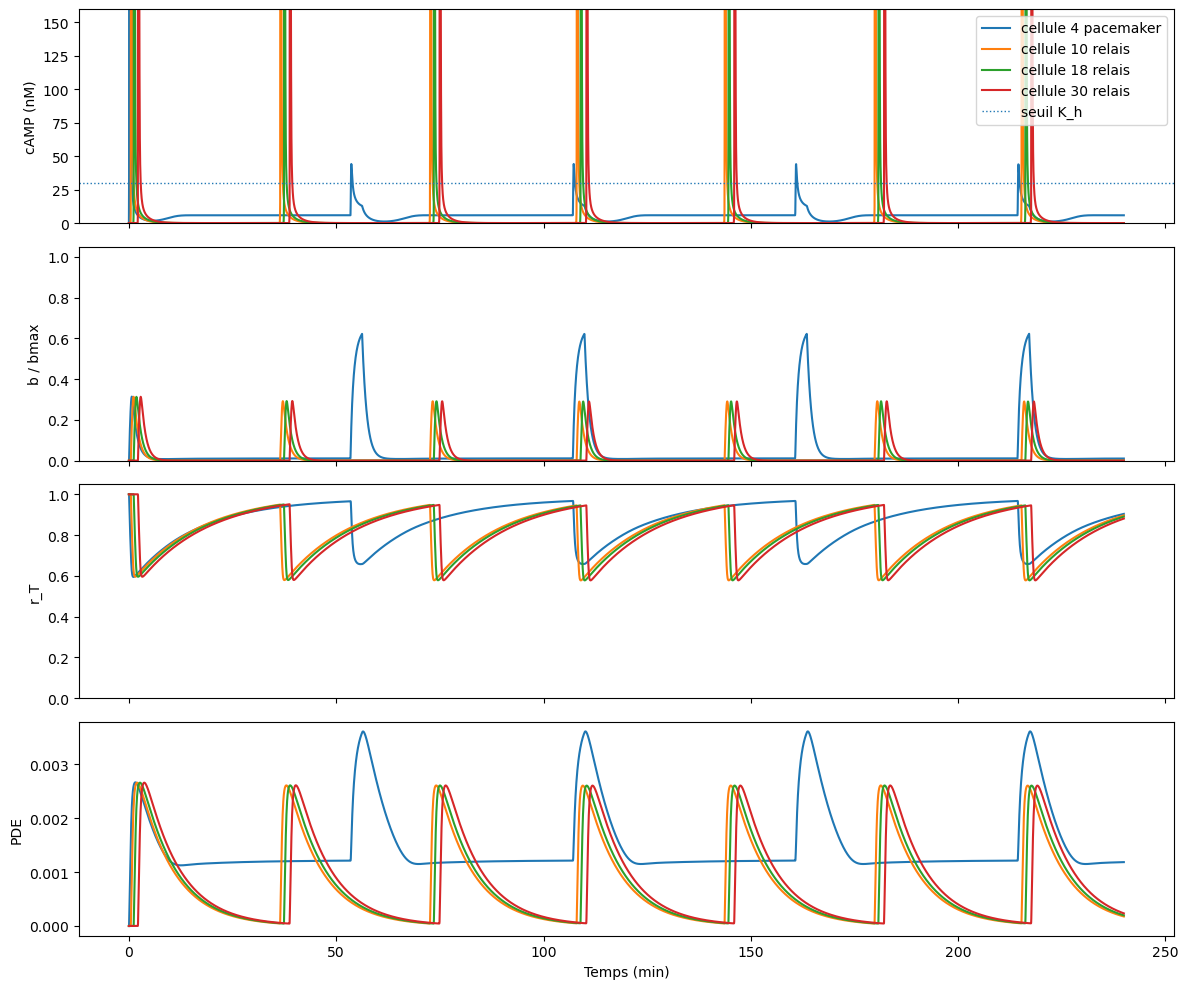

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Test minimal 1D : pionnières + cellules relais couplées par diffusion
# ============================================================
# Objectif : vérifier qu'un petit groupe de cellules pionnières peut déclencher
# des pulses de cAMP qui se diffusent et recrutent des cellules relais.
#
# Ce n'est pas encore le modèle spatial complet de motilité.
# C'est une étape intermédiaire :
#   cellule pionnière autonome -> cAMP diffusible -> cellule relais excitable
#
# Toutes les concentrations sont intégrées en M, mais affichées en nM.

# =========================
# Temps
# =========================

TIME_SIMU = 240.0       # minutes
dt = 0.002              # minutes
n_steps = int(TIME_SIMU / dt)

# =========================
# Géométrie 1D
# =========================

N_CELLS = 40
cell_indices = np.arange(N_CELLS)

# Cellules pionnières : quelques sources au début du domaine.
pacemaker_cells = np.array([3, 4, 5])
is_pacemaker = np.zeros(N_CELLS, dtype=bool)
is_pacemaker[pacemaker_cells] = True

# Diffusion effective entre compartiments voisins.
# Ce coefficient est volontairement phénoménologique pour tester la propagation.
D_eff = 0.22            # 1/min

# Perte globale hors du domaine / dilution minimale.
J = 0.20

# =========================
# Paramètres biochimiques communs
# =========================

# Récepteurs actifs / désensibilisation
F1_base = 0.8
F2_base = 0.06
N_HILL = 4
K_h = 3e-8              # 30 nM

# cAMP intracellulaire b
q_s = 2.0e-5
k_t = 0.9
b_max = q_s / k_t

# Sécrétion du cAMP extracellulaire
K_relay = 3.0e-3

# PDE / RegA
k_PDE = 2e4
PDE_threshold = 3e-8
hill_n_PDE = 2
PDE_rate = 0.004
PDE_decay = 0.12
PDE_inhibition_threshold = 8.0e-5

# Cellules relais : pas d'activité basale autonome.
f0_relay = 0.0

# Cellules pionnières : faible activité basale + pulse autonome.
f0_pacemaker = 0.01

# =========================
# Paramètres pacemaker
# =========================

A = np.zeros(N_CELLS)
A[is_pacemaker] = 0.02
A_recovery_rate = 0.030
A_min = 0.02
A_max = 1.0
A_trigger = 0.75
A_reset = 0.04

pulse_active = np.zeros(N_CELLS, dtype=bool)
pulse_timer = np.zeros(N_CELLS)
pulse_duration = 2.8       # minutes
pulse_strength = 1.0

# =========================
# Conditions initiales
# =========================

c = np.zeros(N_CELLS)       # cAMP extracellulaire local
b = np.zeros(N_CELLS)       # cAMP intracellulaire
r_T = np.ones(N_CELLS)      # fraction de récepteurs actifs
PDE = np.zeros(N_CELLS)

# =========================
# Traces
# =========================

save_every = 20
times = []
c_history = []
b_history = []
r_history = []
pde_history = []
A_history = []
pulse_history = []

# Quelques cellules à suivre individuellement.
tracked_cells = [4, 10, 18, 30]
tracked = {idx: {"c": [], "b": [], "r": [], "PDE": [], "F": []} for idx in tracked_cells}
tracked_time = []

# =========================
# Fonctions utilitaires
# =========================

def laplacian_reflective(x: np.ndarray) -> np.ndarray:
    """Laplacien 1D avec bords réfléchissants."""
    lap = np.zeros_like(x)
    lap[1:-1] = x[:-2] - 2.0 * x[1:-1] + x[2:]
    lap[0] = x[1] - x[0]
    lap[-1] = x[-2] - x[-1]
    return lap

# =========================
# Simulation
# =========================

for step in range(n_steps):
    t = step * dt

    c_pos = np.maximum(c, 0.0)
    hill_c = c_pos**N_HILL / (K_h**N_HILL + c_pos**N_HILL + 1e-60)

    # -------------------------
    # Déclenchement pacemaker
    # -------------------------
    can_trigger = (
        is_pacemaker
        & (~pulse_active)
        & (A >= A_trigger)
        & (r_T > 0.8)
        & (hill_c < 0.2)
    )
    pulse_active[can_trigger] = True
    pulse_timer[can_trigger] = pulse_duration
    A[can_trigger] = A_reset

    pacemaker_drive = np.zeros(N_CELLS)
    pacemaker_drive[pulse_active] = pulse_strength

    pulse_timer[pulse_active] -= dt
    ended = pulse_active & (pulse_timer <= 0.0)
    pulse_active[ended] = False
    pulse_timer[ended] = 0.0

    # -------------------------
    # Activation cellulaire
    # -------------------------
    f0 = np.where(is_pacemaker, f0_pacemaker, f0_relay)
    activation = f0 + pacemaker_drive + (1.0 - f0) * hill_c
    activation = np.minimum(activation, 1.0)

    F_val = r_T * activation

    # -------------------------
    # PDE et inhibition
    # -------------------------
    f1_eff = F1_base * hill_c
    pde_prod = PDE_rate * c_pos**hill_n_PDE / (
        PDE_threshold**hill_n_PDE + c_pos**hill_n_PDE + 1e-60
    )
    inhibition = 1.0 / (1.0 + (PDE / PDE_inhibition_threshold)**2)

    # -------------------------
    # Production et dégradation cAMP
    # -------------------------
    camp_prod = K_relay * (b / b_max) * inhibition
    camp_deg = J * c + k_PDE * PDE * c
    diffusion = D_eff * laplacian_reflective(c)

    dc = camp_prod - camp_deg + diffusion
    db = q_s * F_val - k_t * b
    dr = -f1_eff * r_T + F2_base * (1.0 - r_T)
    dPDE = pde_prod - PDE_decay * PDE

    # -------------------------
    # Récupération pacemaker
    # -------------------------
    dA = np.zeros(N_CELLS)
    recovering = is_pacemaker & (~pulse_active)
    recovery_drive = r_T * (1.0 - hill_c)
    dA[recovering] = A_recovery_rate * recovery_drive[recovering] * (A_max - A[recovering])

    # -------------------------
    # Intégration Euler
    # -------------------------
    c += dc * dt
    b += db * dt
    r_T += dr * dt
    PDE += dPDE * dt
    A += dA * dt

    c = np.maximum(c, 0.0)
    b = np.maximum(b, 0.0)
    r_T = np.clip(r_T, 0.0, 1.0)
    PDE = np.maximum(PDE, 0.0)
    A = np.clip(A, A_min, A_max)

    # -------------------------
    # Sauvegarde
    # -------------------------
    if step % save_every == 0:
        times.append(t)
        c_history.append(c.copy())
        b_history.append((b / b_max).copy())
        r_history.append(r_T.copy())
        pde_history.append(PDE.copy())
        A_history.append(A.copy())
        pulse_history.append(pulse_active.astype(float).copy())

        tracked_time.append(t)
        for idx in tracked_cells:
            tracked[idx]["c"].append(c[idx] * 1e9)
            tracked[idx]["b"].append(b[idx] / b_max)
            tracked[idx]["r"].append(r_T[idx])
            tracked[idx]["PDE"].append(PDE[idx])
            tracked[idx]["F"].append(F_val[idx])

# Conversion en tableaux

times = np.array(times)
c_history = np.array(c_history) * 1e9
b_history = np.array(b_history)
r_history = np.array(r_history)
pde_history = np.array(pde_history)
A_history = np.array(A_history)
pulse_history = np.array(pulse_history)
tracked_time = np.array(tracked_time)

# =========================
# Diagnostics
# =========================

print(f"cAMP max global = {np.nanmax(c_history):.2f} nM")
for idx in tracked_cells:
    print(
        f"cellule {idx:02d} | cAMP max = {np.nanmax(tracked[idx]['c']):7.2f} nM | "
        f"b/bmax max = {np.nanmax(tracked[idx]['b']):.3f} | "
        f"r_T min = {np.nanmin(tracked[idx]['r']):.3f}"
    )

# =========================
# Affichage spatial
# =========================

fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

im0 = axes[0].imshow(
    c_history.T,
    aspect="auto",
    origin="lower",
    extent=[times[0], times[-1], 0, N_CELLS - 1],
    vmin=0,
    vmax=120,
)
axes[0].set_ylabel("Cellule")
axes[0].set_title("cAMP extracellulaire local (nM)")
plt.colorbar(im0, ax=axes[0], label="nM")

im1 = axes[1].imshow(
    b_history.T,
    aspect="auto",
    origin="lower",
    extent=[times[0], times[-1], 0, N_CELLS - 1],
    vmin=0,
    vmax=1,
)
axes[1].set_ylabel("Cellule")
axes[1].set_title("b / bmax")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(
    r_history.T,
    aspect="auto",
    origin="lower",
    extent=[times[0], times[-1], 0, N_CELLS - 1],
    vmin=0,
    vmax=1,
)
axes[2].set_ylabel("Cellule")
axes[2].set_title("Récepteurs actifs r_T")
plt.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(
    pulse_history.T,
    aspect="auto",
    origin="lower",
    extent=[times[0], times[-1], 0, N_CELLS - 1],
    vmin=0,
    vmax=1,
)
axes[3].set_ylabel("Cellule")
axes[3].set_xlabel("Temps (min)")
axes[3].set_title("Pulses pacemaker")
plt.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()

# =========================
# Affichage de quelques traces individuelles
# =========================

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

for idx in tracked_cells:
    label = f"cellule {idx}" + (" pacemaker" if is_pacemaker[idx] else " relais")
    axes[0].plot(tracked_time, tracked[idx]["c"], label=label)
axes[0].axhline(K_h * 1e9, linestyle=":", linewidth=1, label="seuil K_h")
axes[0].set_ylabel("cAMP (nM)")
axes[0].set_ylim(0, 160)
axes[0].legend(loc="upper right")

for idx in tracked_cells:
    axes[1].plot(tracked_time, tracked[idx]["b"], label=f"cellule {idx}")
axes[1].set_ylabel("b / bmax")
axes[1].set_ylim(0, 1.05)

for idx in tracked_cells:
    axes[2].plot(tracked_time, tracked[idx]["r"], label=f"cellule {idx}")
axes[2].set_ylabel("r_T")
axes[2].set_ylim(0, 1.05)

for idx in tracked_cells:
    axes[3].plot(tracked_time, tracked[idx]["PDE"], label=f"cellule {idx}")
axes[3].set_ylabel("PDE")
axes[3].set_xlabel("Temps (min)")

plt.tight_layout()
plt.show()